# MeRN Quick Start Tutorial

## Metabolic Representation Net (MeRN)

Single-cell RNA-seq data provides rich information about gene expression across thousands of cells, but interpreting **cellular metabolism** from transcriptomic data alone is challenging. Many metabolic processes are coordinated across genes and reactions, making them difficult to capture with standard dimensionality reduction methods.

**Metabolic Representation Net (MeRN)** is a graph-guided variational autoencoder designed to infer metabolic state from single-cell transcriptomic data.

Standard VAEs such as **scVI** learn low-dimensional latent representations of cells and decode them to gene-level parameters using flexible neural networks. While these models capture complex transcriptional structure, the latent dimensions are not explicitly linked to metabolic processes.

MeRN introduces a **metabolic prior** by leveraging a metabolic reaction graph, where:

- **nodes** represent metabolic reactions  
- **edges** connect reactions that share metabolites

A graph VAE learns embeddings of this reaction network, and the cell-level latent space is decomposed into two components:

• **Metabolic variation**: variation explained by metabolic reactions  
• **Background variation**: non-metabolic transcriptional variation

This structure links latent dimensions to **reaction activity and enzyme-coding genes**, enabling interpretable metabolic representations.

In this tutorial, we apply MeRN to a mouse embryogenesis single-cell RNA-seq dataset. We will:

1. Load the preprocessed wild-type embryogenesis dataset.
2. Fit or load a pretrained MeRN model.
3. Extract metabolic and background cell embeddings.
4. Analyze the metabolic latent space with UMAP and clustering.
5. Decode reaction activity for every cell.
6. Aggregate reaction activity into KEGG pathway scores.
7. Build data-driven pathways (DDPs), which group graph-connected reactions with coordinated activity across cells.
8. Compare reaction, KEGG pathway, and DDP activity across metabolic clusters.
9. Visualize glycolysis/gluconeogenesis on KEGG pathway graphs, colored by DDP membership and by differential reaction activity.
10. Expand a KEGG pathway by plotting all reactions in DDPs connected to glycolysis.
11. Compare DDP structure between wild-type and *Folr1* knockout embryos in a matched metabolic
    state. Steps 1-10 use the wild type alone; the knockout enters only in this step, as its own
    cells (embedded with the wild-type model to map them onto the wild-type metabolic states) and
    a precomputed table of its decoded reaction activity.

The tutorial emphasizes DDPs as a data-driven interpretation layer between individual reactions and broad canonical pathways. Reactions are highly granular, while KEGG pathways are predefined and often broad. DDPs provide coordinated metabolic reaction programs learned from the data and constrained by the metabolic graph.

![MeRN Architecture](figures/mern_architecture.png)

### Files and Folder Structure
```text
tutorials/
├── MeRN_tutorial.ipynb
├── data/
│   ├── main_wt_anndata_pp_subsample.h5ad.gz     wild-type cells: log1p `X`, raw `counts_RNA`
│   ├── folr1_anndata_subsample.h5ad.gz          Folr1 knockout cells, same gene space
│   ├── folr1_average_enzyme_activity.csv.gz     knockout reaction activity
│   └── wt_ref_color_mapping.csv                 cell-type colors used in the paper's figures
├── figures/                                     figures written by the notebook
└── model/
    └── mern_rep_0/ … mern_rep_4/
        ├── model.pt.gz                          pretrained replicate checkpoints
        └── metabolic_clustering_0.4.csv         paper's metabolic clusters (mern_rep_0 only)
```

In [1]:
from scvi.train._callbacks import SaveCheckpoint
from mern import MERN
import mern.support as mern_support
import anndata as ad
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import os
import plotly.colors as pc
from contextlib import contextmanager
from IPython.display import display

/Users/daniellewinsohn/miniforge3/envs/mern-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_new_model = False
clustering_res = 0.4
chosen_rep = 0
n_reps = 5

base_path_data = 'data'
base_path_model = 'model'
base_path_figures = 'figures'

wt_adata_file = 'main_wt_anndata_pp_subsample.h5ad.gz'
folr1_adata_file = 'folr1_anndata_subsample.h5ad.gz'
folr1_activity_file = 'folr1_average_enzyme_activity.csv.gz'
color_mapping_file = 'wt_ref_color_mapping.csv'

suffix = f'_rep{chosen_rep}'
metabolic_key = f"X_mern_metabolic{suffix}"
background_key = f"X_mern_background{suffix}"
metabolic_umap_key = f"X_umap_metabolic{suffix}"
background_umap_key = f"X_umap_background{suffix}"
graph_key = f"graph{suffix}"

### Unpacking the Checkpoints

The replicate checkpoints are gzipped and must be decompressed in place the first time the tutorial is run.


In [3]:
import gzip
import shutil
from pathlib import Path

for archive in sorted(Path(base_path_model).glob('mern_rep_*/model.pt.gz')):
    checkpoint = archive.with_suffix('')
    if checkpoint.exists():
        continue
    print(f'unpacking {archive}')
    with gzip.open(archive) as src, open(checkpoint, 'wb') as dst:
        shutil.copyfileobj(src, dst)

print('checkpoints ready:', sorted(p.parent.name for p in Path(base_path_model).glob('mern_rep_*/model.pt')))


checkpoints ready: ['mern_rep_0', 'mern_rep_1', 'mern_rep_2', 'mern_rep_3', 'mern_rep_4']


### Figure Colors

A small color registry keeps the figures in this tutorial consistent.

In [4]:
TEXT_COLOR = '#222222'
STRUCTURE_COLOR = '#666666'
BACKGROUND_COLOR = '#A7ADB8'
MISSING_COLOR = '#CFCFCF'
OBSERVED_COLOR = '#0072B2'
HIGHLIGHT_COLOR = '#D55E00'

METHOD_PALETTE = {
    'mern': '#0072B2',
    'rna': '#E69F00',
    'scrna': '#009E73',
    'prot': '#222222',
    'kegg_metroscreen': '#CC79A7',
    'compass': '#56B4E9',
}

GENOTYPE_PALETTE = {
    'WT': '#7A7A7A',
    'Folr1': '#8C6BB1',
    'Folr1 KO': '#8C6BB1',
}

# Cell-type colors as used in the manuscript figures
CELLTYPE_COLORS = pd.read_csv(f'{base_path_data}/{color_mapping_file}')
CELLTYPE_PALETTE = dict(zip(CELLTYPE_COLORS['cell_type'], CELLTYPE_COLORS['colors']))

GERMLAYER_PALETTE = {
    'Epiblast': '#000000',
    'PrimitiveStreak': '#808080',
    'GermCell': '#DB083D',
    'Endoderm': '#F5F200',
    'XMesoderm': '#00C4ED',
    'AxialMesoderm': '#0000FC',
    'Mesoderm': '#910299',
    'NeuralEctoderm': '#008C2A',
    'NonNeuralEctoderm': '#334513',
}

PHASE_PALETTE = {
    'G0/G1': '#4C78A8',
    'S': '#F2CF5B',
    'G2': '#72B7B2',
    'M': '#B279A2',
}

HEATMAP_CMAP = mpl.colormaps['viridis']

def reset_plotting_defaults():
    """Editable-text vector output and a consistent typeface."""
    mpl.rcdefaults()
    sns.reset_defaults()
    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'axes.spines.top': False,
        'axes.spines.right': False,
        'legend.frameon': False,
        'figure.dpi': 150,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'svg.fonttype': 'none',
    })

reset_plotting_defaults()

def styled_theme(**kwargs):
    """`sns.set_theme` that keeps this tutorial's typeface and editable-text vector output."""
    kwargs.setdefault('font', 'Arial')
    rc = {
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'svg.fonttype': 'none',
        'legend.frameon': False,
    }
    rc.update(kwargs.pop('rc', {}))
    sns.set_theme(rc=rc, **kwargs)

def top_features_per_cluster(z_scored, n_per_cluster):
    """The union of each cluster's most distinctive features, in nominating-cluster order.

    Ranking by variance across clusters says nothing about *which* cluster a feature belongs to, so
    a cluster whose features are all moderately elevated can go unrepresented. Taking each
    cluster's highest z-scores guarantees every cluster is characterised, and groups the rows into
    blocks that can be read against the columns.
    """
    picked = []
    for cluster in z_scored.columns:
        picked += z_scored[cluster].sort_values(ascending=False).head(n_per_cluster).index.tolist()
    return list(dict.fromkeys(picked))

def ddp_palette_sequence(labels):
    """Colors for a set of DDP labels, taken in order from Plotly's Dark24.

    DDP identifiers come from the clustering order, so they are specific to the cells a DDP set was
    built on. Colors are assigned by position rather than by identifier for that reason.
    """
    categories = list(pd.Series(labels).dropna().unique())
    palette = list(pc.qualitative.Dark24)
    return [palette[i % len(palette)] for i in range(len(categories))]

def ddp_color_map_for(labels):
    """DDP label -> color, for the `ddp_color_map` argument of the pathway plots."""
    categories = list(pd.Series(labels).dropna().unique())
    return dict(zip(categories, ddp_palette_sequence(categories)))

@contextmanager
def ddp_pathway_palette(labels):
    """The pathway plots color discrete edge labels from Plotly's Set1, in order of first
    appearance. Swap the DDP registry in for the duration of one plot."""
    original = pc.qualitative.Set1
    pc.qualitative.Set1 = ddp_palette_sequence(labels)
    try:
        yield
    finally:
        pc.qualitative.Set1 = original

# --- Pathway plot labels ---------------------------------------------------
KEY_METABOLITE_IDS = [
    'cpd:C00267',  # alpha-D-Glucose
    'cpd:C00031',  # D-Glucose
    'cpd:C00668',  # alpha-D-Glucose 6-phosphate
    'cpd:C00085',  # D-Fructose 6-phosphate
    'cpd:C00354',  # D-Fructose 1,6-bisphosphate
    'cpd:C00111',  # Glycerone phosphate
    'cpd:C00118',  # D-Glyceraldehyde 3-phosphate
    'cpd:C00236',  # 3-Phospho-D-glyceroyl phosphate
    'cpd:C00197',  # 3-Phospho-D-glycerate
    'cpd:C00631',  # 2-Phospho-D-glycerate
    'cpd:C00074',  # Phosphoenolpyruvate
    'cpd:C00022',  # Pyruvate
    'cpd:C00186',  # (S)-Lactate
]

ANCHOR_METABOLITE_IDS = ['cpd:C00267', 'cpd:C00022', 'cpd:C00186']

def pathway_compound_nodes(dataset, pathway=None, rxns=None):
    """The compound nodes a pathway plot will draw.

    Mirrors the node construction inside `kegg_pathway_plot` / `custom_pathway_plot`, so a label
    choice can be checked against the figure before plotting instead of silently going missing.
    """
    if (pathway is None) == (rxns is None):
        raise ValueError('pass exactly one of `pathway` or `rxns`')
    wanted = set(rxns) if rxns is not None else None
    nodes = set()
    for reaction in dataset.rxns:
        if wanted is None:
            in_pathway = any(
                pathway in [p[0] for p in dataset.rxn_info[r.split('rn:')[1]]['PATHWAY']]
                for r in reaction.name.split(' ')
            )
            if not in_pathway:
                continue
        elif reaction.name not in wanted:
            continue
        nodes.update(compound.name for compound in reaction.substrates)
        nodes.update(compound.name for compound in reaction.products)
    return nodes


def metabolite_labels(dataset, pathway=None, rxns=None, require_anchors=True):
    """`labeled_nodes` for a pathway plot: the key metabolites this particular plot contains.

    A compound ID that is not a node in the plot would simply never be drawn, so when
    `require_anchors` is set a missing anchor raises instead of quietly losing its label.
    """
    present = pathway_compound_nodes(dataset, pathway=pathway, rxns=rxns)
    if require_anchors:
        missing = [c for c in ANCHOR_METABOLITE_IDS if c not in present]
        if missing:
            raise ValueError(
                f'anchor metabolites absent from this plot: {missing}. '
                'Check the IDs against `dataset.compound_info`.'
            )
    return [c for c in KEY_METABOLITE_IDS if c in present]

### Loading the WT Dataset

The wild-type dataset here is a subsample of the original full embryogenesis data `main_wt_anndata_pp.h5ad.gz`. The pretrained models are the published ones.

Cells outside the embryo proper (the `Blood&Vas`, `XEctoderm`, and `XEndoderm`
germ layers) and genes detected in fewer than 100 cells were already removed from the full object,
so no further preprocessing is needed here.

The feature space is the object's own `highly_variable_metabolic` / `highly_variable_background`
flags, sorted (800 metabolic & 5,000 background genes). Commented code shows how to calculate highly variable genes for your own dataset.

`X` is already log1p-normalized; `layers['counts_RNA']` holds the raw counts the model reads.

In [5]:
rna_full = ad.read_h5ad(f'{base_path_data}/{wt_adata_file}')

dataset = mern_support.KeggKGMLMetabolicDataset(species='mouse', capitalize=False)
dataset.add_module_info(rna_full)

# calculate highly variable genes yourself
"""temp_rna = rna_full[:, rna_full.var['Metabolic Gene'] == 'Metabolic']
sc.pp.highly_variable_genes(temp_rna, n_top_genes=800, flavor="seurat_v3", layer="counts_RNA")
sc.pl.highly_variable_genes(temp_rna, log=True)
met_hvgs = list(temp_rna.var_names[temp_rna.var["highly_variable"]])
temp_rna = rna_full[:, rna_full.var['Metabolic Gene'] == 'Non-metabolic']
sc.pp.highly_variable_genes(temp_rna, n_top_genes=5000, flavor="seurat_v3", layer="counts_RNA")
sc.pl.highly_variable_genes(temp_rna, log=True)
back_hvgs = list(temp_rna.var_names[temp_rna.var["highly_variable"]])
rna_full.var['highly_variable_metabolic'] = [True if gene in met_hvgs else False for gene in rna_full.var.index]
rna_full.var['highly_variable_background'] = [True if gene in back_hvgs else False for gene in rna_full.var.index]"""

features_to_use = sorted(
    rna_full.var_names[
        rna_full.var['highly_variable_metabolic'] | rna_full.var['highly_variable_background']
    ]
)
rna = rna_full[:, features_to_use].copy()

met_g = dataset.metabolic_topology(rna, self_loops=False)
dataset.add_rxn_module_info(rna, met_g)
dataset.add_rxn_module_info(rna_full, met_g)
rxn_genes = dataset.get_rxn_genes_all()

rna_full.layers['log1p_norm'] = rna_full.X
rna.layers['log1p_norm'] = rna.X

rxn_info = rna.uns["Reaction Info"]
rxn_ids = rxn_info.index.to_list()

print(rna)
print(rna.var['Metabolic Gene'].value_counts())


Initiating one-time download from KEGG for mouse: mmu reaction metadata. This uses KEGG access provided for academic use by academic users; you are responsible for complying with KEGG's terms. the result will be cached in /Users/daniellewinsohn/.cache/mern/kegg and reused.


100%|██████████| 169/169 [02:09<00:00,  1.31it/s]


Initiating one-time download from KEGG for mouse: mmu compound metadata. This uses KEGG access provided for academic use by academic users; you are responsible for complying with KEGG's terms. the result will be cached in /Users/daniellewinsohn/.cache/mern/kegg and reused.


100%|██████████| 123/123 [01:47<00:00,  1.15it/s]


AnnData object with n_obs × n_vars = 6000 × 5800
    obs: 'nCount_RNA', 'nFeature_RNA', 'log_count', 'percent.mt', 'sex', 'embryo_id', 'sample_group', 'timepoint', 'cell_type', 'germlayer'
    var: 'names', 'n_cells', 'Gene Reactions', 'Metabolic Gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_metabolic', 'highly_variable_background'
    uns: 'hvg', 'Reaction Info'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts_RNA', 'log1p_norm'
Metabolic Gene
Non-metabolic    5000
Metabolic         800
Name: count, dtype: int64


In [6]:
for adata_obj in [rna, rna_full]:
    for col in ('cell_type', 'germlayer'):
        if col in adata_obj.obs:
            adata_obj.obs[col] = adata_obj.obs[col].astype('category')

    if 'germlayer' in adata_obj.obs:
        adata_obj.uns['germlayer_colors'] = [
            GERMLAYER_PALETTE.get(cat, MISSING_COLOR)
            for cat in adata_obj.obs['germlayer'].cat.categories
        ]

    if 'cell_type' in adata_obj.obs:
        adata_obj.uns['cell_type_colors'] = [
            CELLTYPE_PALETTE.get(cat, MISSING_COLOR)
            for cat in adata_obj.obs['cell_type'].cat.categories
        ]

### Loading or Training a MeRN Model
You can either train a new MeRN model or load the pretrained replicates. With `train_new_model = True`, the cell below sets the loss weights and KL schedule, checkpoints on the validation loss, trains with early stopping, and reloads the best checkpoint. Otherwise (the default), it loads the five pretrained replicate checkpoints: replicate `chosen_rep` supplies the embeddings, and all five are averaged when decoding reaction activity below.

In [7]:
if train_new_model:
    data_dir = 'models'

    plan_kwargs={
        "max_kl_weight": 0.001,
        "graph_kl_weight": 0.1,
        "data_elbo_weight": 1.0,
        "graph_elbo_weight": 0.2,
        "rxn_genes_weight": 0.5,
        "background_to_metabolic_weight": 30000,
        "lr": 0.002,
        "n_steps_kl_warmup": 0,
        "n_epochs_kl_warmup": None
    }

    checkpointing = SaveCheckpoint(
        dirpath=f'{data_dir}/scvi_log_3', monitor="validation_loss", load_best_on_end=False, check_nan_gradients=False
    )
    MERN.setup_anndata(rna, layer='counts_RNA', batch_key=None)
    mern = MERN(rna, met_g, rxn_genes, n_hidden=256, n_layers=2, n_metabolic_dim=25, n_background_dim=15, encode_covariates=False, strict_met_back_separation=True, rxn_genes_bias=True)
    mern.train(accelerator="auto", max_epochs=400, early_stopping=True, early_stopping_monitor="validation_loss", plan_kwargs=plan_kwargs, callbacks = [checkpointing])

    best_mern = MERN.load(checkpointing.best_model_path, rna, accelerator='auto')
    mern = best_mern
    models = [best_mern]
else:
    models_by_rep = {}
    for rep in range(n_reps):
        try:
            models_by_rep[rep] = MERN.load(
                f'{base_path_model}/mern_rep_{rep}', rna, accelerator='cpu'
            )
        except Exception as error:
            print(f'replicate {rep} unavailable ({type(error).__name__})')

    if chosen_rep not in models_by_rep:
        raise RuntimeError(f'replicate {chosen_rep} is required for the embeddings below')

    models = list(models_by_rep.values())
    mern = models_by_rep[chosen_rep]
    print(f'{len(models)} of {n_reps} replicates loaded')


INFO     File model/mern_rep_0/model.pt already downloaded                                                         
INFO     File model/mern_rep_1/model.pt already downloaded                                                         
INFO     File model/mern_rep_2/model.pt already downloaded                                                         
INFO     File model/mern_rep_3/model.pt already downloaded                                                         
INFO     File model/mern_rep_4/model.pt already downloaded                                                         
5 of 5 replicates loaded


### Extracting the Embeddings

The model maps every cell into two latent spaces (a metabolic one tied to the reaction
graph, and a background one for everything else) and every reaction into a graph embedding.
`get_latent_representation` returns all three. It reports the mean of each latent distribution, so
repeated calls give identical answers.

In [8]:
metabolic_latent, background_latent, graph_embedding = mern.get_latent_representation(rna)

rna.obsm[metabolic_key] = metabolic_latent
rna.obsm[background_key] = background_latent
rna.uns[graph_key] = pd.DataFrame(graph_embedding, index=mern.vertex_names_ordered)

print(f'metabolic latent : {metabolic_latent.shape[0]:,} cells x {metabolic_latent.shape[1]} dims')
print(f'background latent: {background_latent.shape[0]:,} cells x {background_latent.shape[1]} dims')
print(f'graph embedding  : {graph_embedding.shape[0]:,} reactions x {graph_embedding.shape[1]} dims')

metabolic latent : 6,000 cells x 25 dims
background latent: 6,000 cells x 15 dims
graph embedding  : 1,213 reactions x 25 dims


## Metabolic and Background Embeddings

MeRN learns two latent embeddings for each cell:

### Background embedding

The background embedding captures non-metabolic transcriptional variation. This can include broad cell identity, developmental programs, technical structure, and other gene expression patterns that are not specifically explained through the metabolic reaction graph.

### Metabolic embedding

The metabolic embedding captures variation that is routed through the metabolic reaction graph. Cells that are transcriptionally similar can still separate in this space if they differ in inferred reaction activity or coordinated metabolic programs.

This embedding is the main space we use to identify metabolic cell states.

By comparing the metabolic and background embeddings, we can ask whether differences between cells are better explained by:

- general transcriptional variation
- metabolic reaction-level variation

In the next cells, we compute neighborhoods, UMAPs, and clusters separately for the metabolic and background embeddings.

### Embedding Clustering

/var/folders/b8/n2yyqb453j9_5kx7s6__03hr0000gn/T/ipykernel_27105/3749321222.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(rna, neighbors_key='met_neighbors', key_added='met_leiden', resolution=clustering_res)


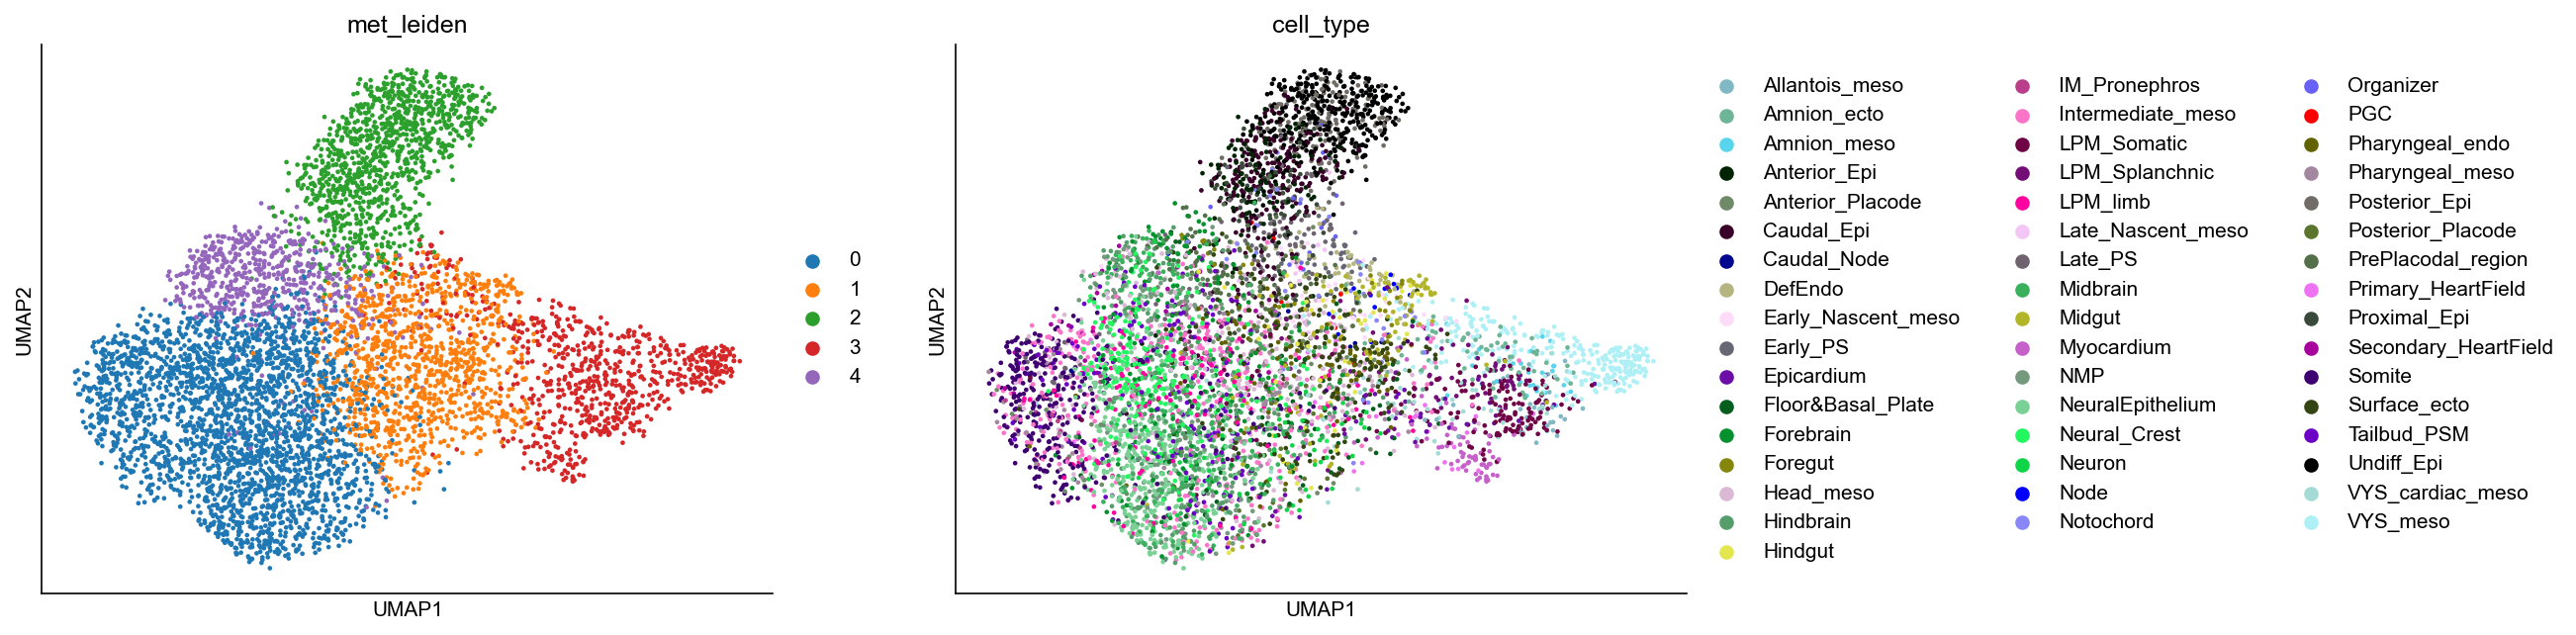

In [9]:
sc.pp.neighbors(rna, use_rep=metabolic_key, key_added='met_neighbors')
sc.tl.umap(rna, neighbors_key='met_neighbors')
sc.tl.leiden(rna, neighbors_key='met_neighbors', key_added='met_leiden', resolution=clustering_res)
sc.pl.umap(rna, color=['met_leiden', 'cell_type'], neighbors_key='met_neighbors')

Because this tutorial uses a subsample of the full dataset, the neighbor graph, UMAP, and Leiden clustering are recomputed on fewer cells. Thus, the UMAP layout differs from the paper's figure, and Leiden partitions the cells slightly differently. We load in the metabolic clusters from the paper below to offer a side by side comparison, but the downstream analyses in this tutorial use the newly computed `met_leiden` clusters.

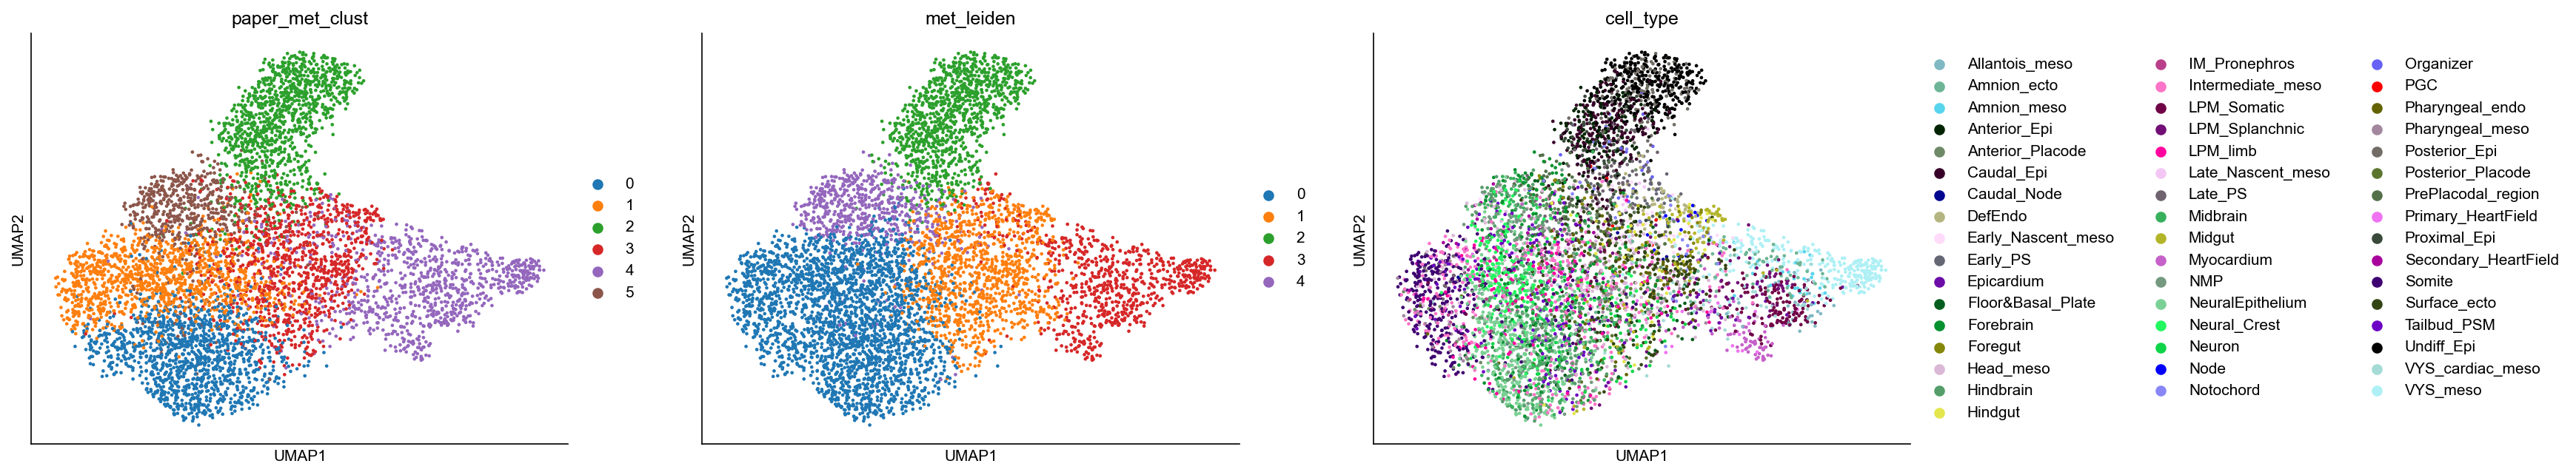

In [10]:
paper_clust_path = './model/mern_rep_0/metabolic_clustering_0.4.csv'
clust = pd.read_csv(paper_clust_path, index_col=0)['Metabolic Clustering_0_0.4']

missing = rna.obs_names.difference(clust.index)
assert len(missing) == 0, f'{len(missing)} cells in rna not found in the clustering CSV, e.g. {list(missing[:5])}'

rna.obs['paper_met_clust'] = clust.reindex(rna.obs_names).astype(str).astype('category')
sc.pl.umap(rna, color=['paper_met_clust', 'met_leiden', 'cell_type'], neighbors_key='met_neighbors')

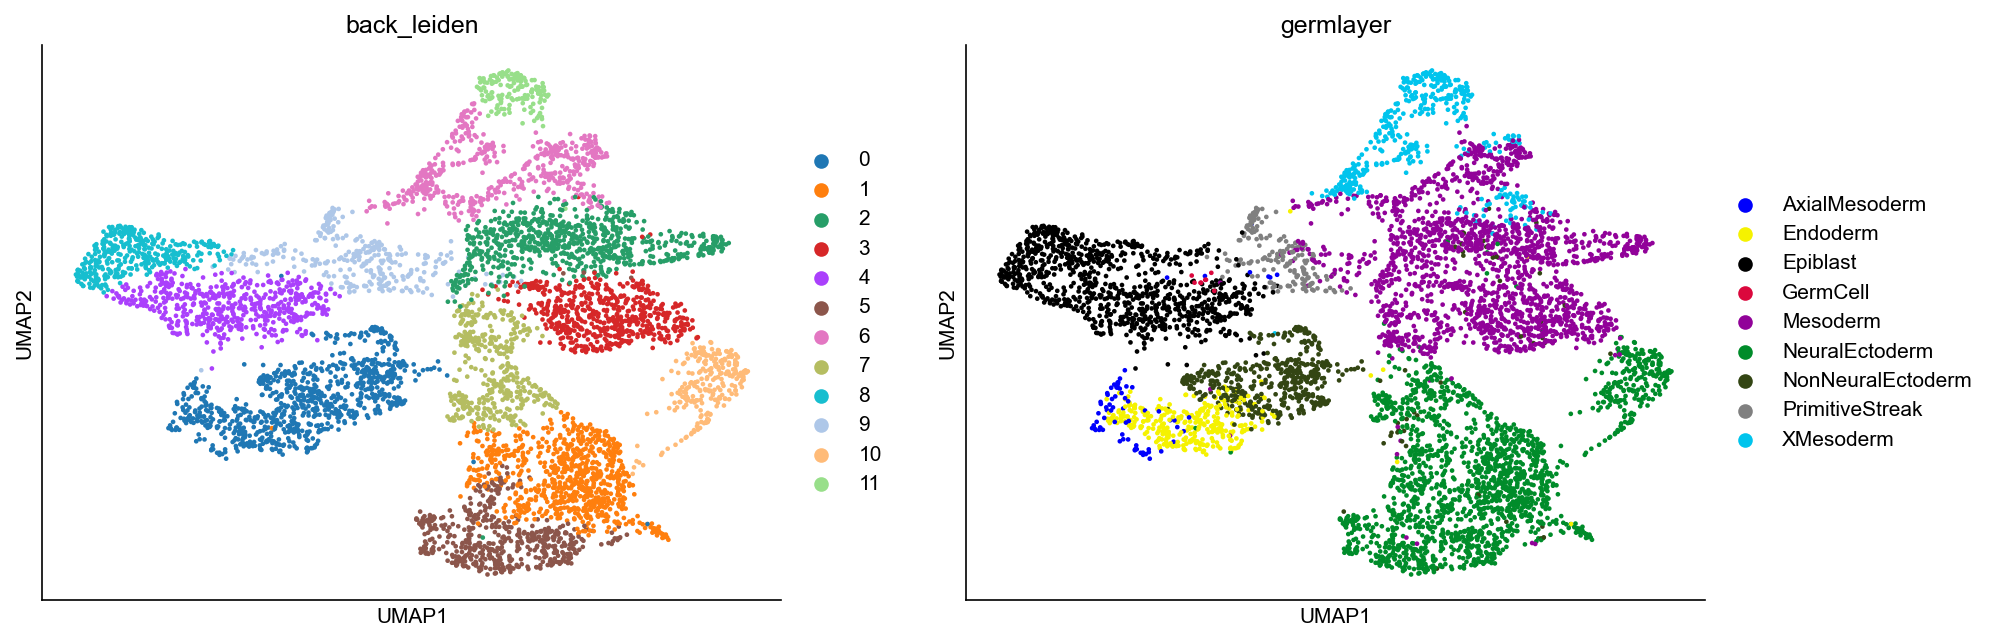

In [11]:
sc.pp.neighbors(rna, use_rep=background_key, key_added='back_neighbors')
sc.tl.umap(rna, neighbors_key='back_neighbors')
sc.tl.leiden(rna, neighbors_key='back_neighbors', key_added='back_leiden', resolution=clustering_res)
sc.pl.umap(rna, color=['back_leiden', 'germlayer'], neighbors_key='back_neighbors')


### Metabolic Embedding Analysis

We cluster cells in the MeRN metabolic embedding to identify metabolic states. To relate these states to embryonic development, we first plot the germ-layer composition of each metabolic cluster, then the proportion of cells in each cluster across timepoints.

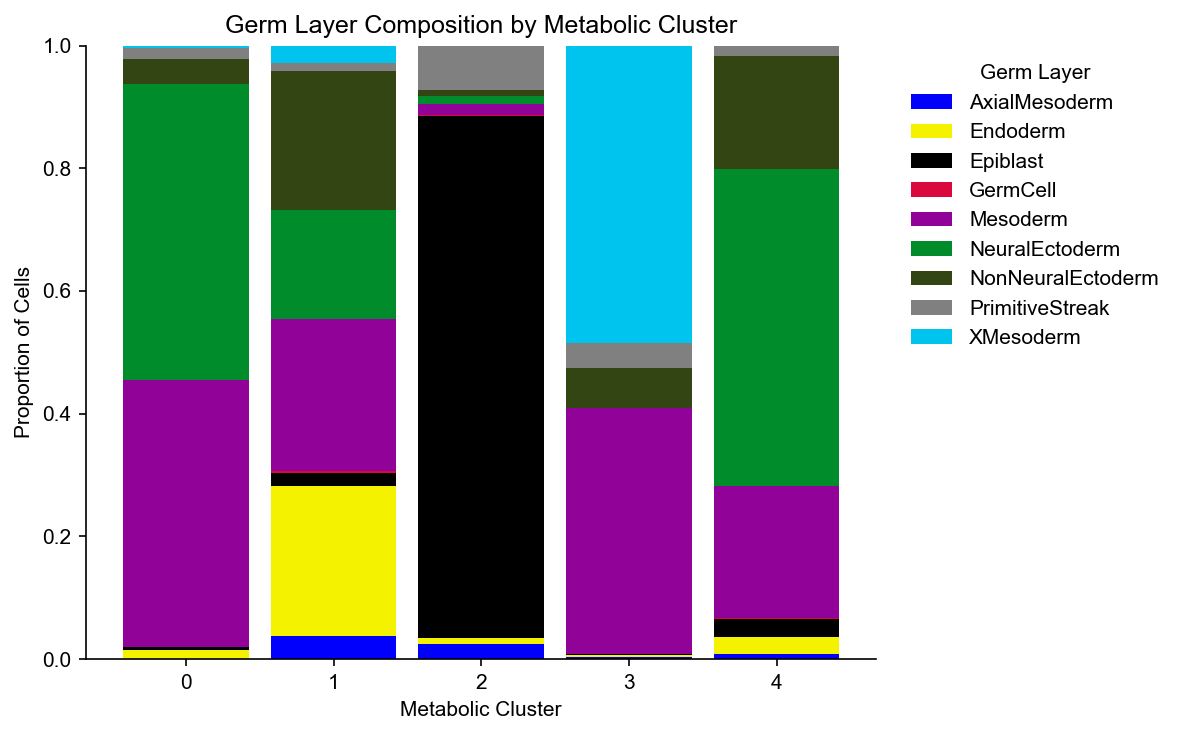

In [12]:
cluster_key = "met_leiden"
group_key = "germlayer"

rna.obs[cluster_key] = rna.obs[cluster_key].astype(str).astype("category")

counts = pd.crosstab(
    rna.obs[cluster_key],
    rna.obs[group_key],
)

props = counts.div(counts.sum(axis=1), axis=0)

germlayer_order = list(rna.obs[group_key].cat.categories)
props = props.reindex(columns=germlayer_order, fill_value=0)

colors = [
    GERMLAYER_PALETTE.get(germlayer, MISSING_COLOR)
    for germlayer in germlayer_order
]

ax = props.plot(
    kind="bar",
    stacked=True,
    color=colors,
    figsize=(8, 5),
    width=0.85,
    edgecolor="none",
)

ax.set_xlabel("Metabolic Cluster")
ax.set_ylabel("Proportion of Cells")
ax.set_title("Germ Layer Composition by Metabolic Cluster")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(
    title="Germ Layer",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()

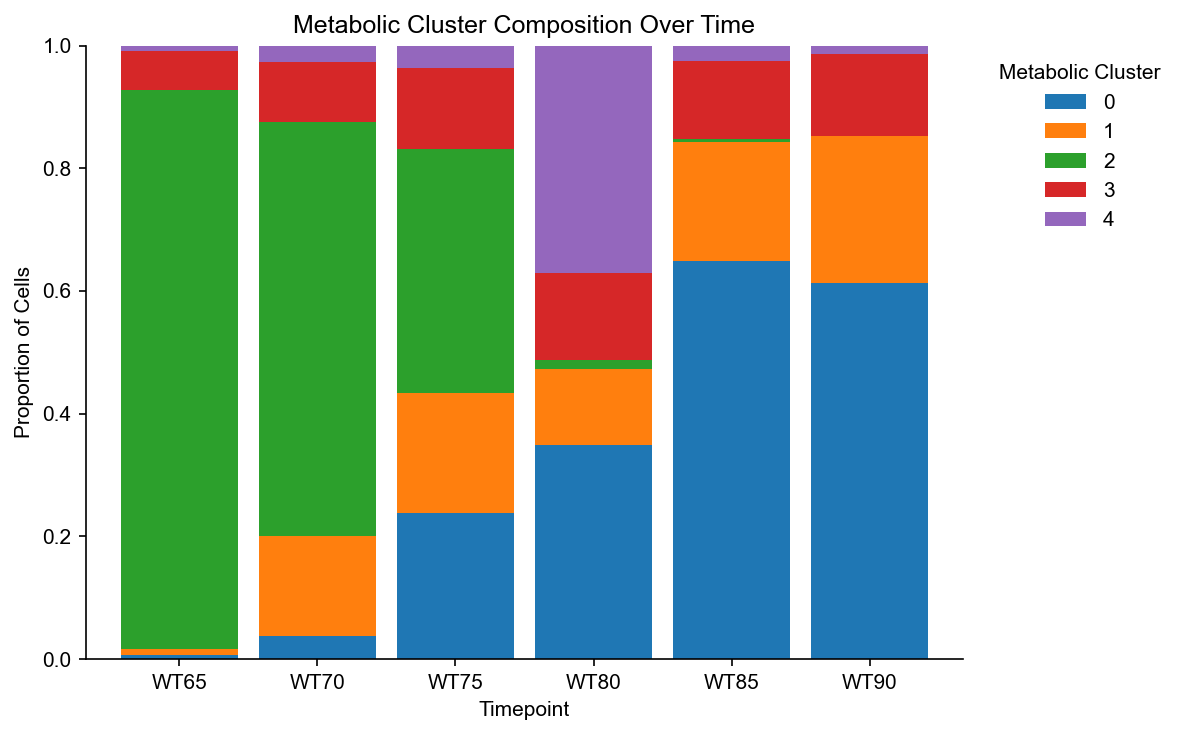

In [13]:
time_key = "timepoint"
cluster_key = "met_leiden"

rna.obs[time_key] = rna.obs[time_key].astype(str).astype("category")
rna.obs[cluster_key] = rna.obs[cluster_key].astype(str).astype("category")

counts = pd.crosstab(
    rna.obs[time_key],
    rna.obs[cluster_key],
)

props = counts.div(counts.sum(axis=1), axis=0)

cluster_order = sorted(
    rna.obs[cluster_key].cat.categories,
    key=lambda x: int(x) if str(x).isdigit() else str(x),
)

props = props.reindex(columns=cluster_order, fill_value=0)

cluster_palette = dict(
    zip(
        cluster_order,
        sns.color_palette("tab10", n_colors=len(cluster_order)).as_hex(),
    )
)

colors = [cluster_palette[c] for c in cluster_order]

ax = props.plot(
    kind="bar",
    stacked=True,
    color=colors,
    figsize=(8, 5),
    width=0.85,
    edgecolor="none",
)

ax.set_xlabel("Timepoint")
ax.set_ylabel("Proportion of Cells")
ax.set_title("Metabolic Cluster Composition Over Time")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(
    title="Metabolic Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()

## Reaction Activity, KEGG Pathway, and DDP Calculations

MeRN decodes each cell into **reaction activity**: how active every metabolic reaction is inferred to be in that cell. From this reaction activity matrix we build two coarser summaries — canonical KEGG pathway scores, and data-driven pathways (DDPs) learned from the data itself.

That gives three activity matrices, at increasing levels of aggregation, which we use throughout the rest of the tutorial:

1. **Reaction activity**: cells × reactions
2. **KEGG pathway activity**: cells × canonical KEGG pathways
3. **DDP activity**: cells × data-driven pathways

Every later section presents these three in the same order, from the finest to the coarsest view.

A note on naming: the package calls this quantity *enzyme activity* in its function and variable names (`mern_support.average_enzyme_activity`, `enzyme_acts_mean`, and the `mern average-enzyme-activity` CLI command). It is the same matrix. This tutorial says **reaction activity** in the text and figures, because the values are indexed by reaction rather than by gene.

![DDPs](figures/ddps.png)

### Decoding Reaction Activity

MeRN decodes each cell into reaction-level activity: a cells x reactions matrix giving the
activity inferred for each reaction in each cell.

Decoding is stochastic, and separately trained replicates differ from one another, so the activity
used for analysis is averaged rather than taken from a single decode.
`mern_support.average_enzyme_activity` handles both: it decodes `n_samples` times per model and
averages across every replicate it is given.

To demonstrate, we average 8 decodes from each of the 5 included replicates below.

In [16]:
enzyme_acts_mean = mern_support.average_enzyme_activity(models, rna, n_samples=8, show_progress=False)

enzyme_acts_mean

Seed set to 8
Seed set to 9
Seed set to 10
Seed set to 11
Seed set to 12
Seed set to 13
Seed set to 14
Seed set to 15
Seed set to 1008
Seed set to 1009
Seed set to 1010
Seed set to 1011
Seed set to 1012
Seed set to 1013
Seed set to 1014
Seed set to 1015
Seed set to 2008
Seed set to 2009
Seed set to 2010
Seed set to 2011
Seed set to 2012
Seed set to 2013
Seed set to 2014
Seed set to 2015
Seed set to 3008
Seed set to 3009
Seed set to 3010
Seed set to 3011
Seed set to 3012
Seed set to 3013
Seed set to 3014
Seed set to 3015
Seed set to 4008
Seed set to 4009
Seed set to 4010
Seed set to 4011
Seed set to 4012
Seed set to 4013
Seed set to 4014
Seed set to 4015


,rn:R00351 rn:R00352,rn:R00209 rn:R00212 rn:R01196 rn:R10866,rn:R00341 rn:R00345 rn:R00346 rn:R00431 rn:R00726,rn:R00217 rn:R00344 rn:R12212,rn:R00705 rn:R00706,rn:R00233 rn:R00353 rn:R00742,rn:R00357,rn:R03858,rn:R04742,rn:R03778,...,rn:R13391,rn:R05923,rn:R05924,rn:R13395,rn:R13402,rn:R13408,rn:R08781,rn:R02161,rn:R13224,rn:R00081
WT65_1_CTCCCAATCATCAGTG-1,0.501264,1.423109,2.900505,3.117703,0.000221,0.068973,2.125863,0.016358,0.000005,0.023986,...,0.319463,0.142891,0.198835,1.290856,0.185172,0.681304,0.739687,0.836421,0.744113,0.715358
WT65_1_TCTAACTGTCATCACA-1,1.279655,3.017212,3.519320,4.090299,0.337239,0.263835,1.991866,0.169117,0.341080,0.383189,...,0.316503,0.226324,0.325084,1.498919,0.420310,0.674704,0.971236,0.957889,0.720279,0.787069
WT65_1_AGCATCACACTGCACG-1,0.725717,2.303315,3.178614,3.547062,0.339189,0.098212,1.816407,0.094003,0.133307,0.164853,...,0.313879,0.073306,0.220451,1.530750,0.208325,0.738438,0.780331,0.806572,0.639561,0.935785
WT65_1_AAGAACAAGAATCGCG-1,1.099178,2.751644,4.373340,4.908928,0.161633,0.194620,3.403841,0.030333,0.129293,0.221094,...,0.345708,0.251665,0.309978,1.668479,0.138314,0.823985,1.123434,1.070077,0.885505,0.925709
WT65_1_AGACAAATCCAACCGG-1,2.997977,5.055899,4.469263,5.092192,1.186582,0.907151,2.681515,0.951997,1.271756,1.186453,...,0.424448,0.188741,0.228933,1.538487,0.193824,0.888587,0.930118,0.985039,0.904613,1.042986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WT90_4_GTAGTACTCCGCGATG-1,3.265272,3.250404,3.044608,2.534521,1.608961,1.359930,1.974718,1.303628,1.182495,1.662586,...,0.904989,1.096877,1.089835,0.571538,0.570002,0.370623,0.285955,0.521686,0.706695,0.721114
WT90_4_GCCGATGCACGGGCTT-1,0.677042,0.701352,0.686832,0.687992,0.317901,0.972473,0.179103,0.698784,0.644020,0.988871,...,0.899537,0.840459,0.962301,0.739031,0.671718,1.796167,2.410409,2.895690,2.117692,2.157468
WT90_4_TCGTGCTAGAGCCGAT-1,1.484363,1.678304,2.925100,2.490174,0.287045,0.450374,1.648407,0.403327,0.551135,0.402139,...,0.421659,1.402514,1.293007,0.570563,1.221698,2.419944,3.681092,4.067152,2.563948,3.034113
WT90_4_CAGATACCACCCTTGT-1,4.127961,3.907559,1.786773,1.759523,3.567367,3.800569,2.153339,3.464602,3.574801,3.677756,...,0.433399,0.189135,0.400398,0.490558,0.708944,1.966772,2.870537,2.760200,2.104390,2.124063


### Calculating KEGG Pathway Scores

The first summary of reaction activity is the canonical one: KEGG's own pathway definitions.

The input reaction activity matrix contains cells as rows and metabolic reactions as columns. Using the reaction metadata in `rxn_info`, each reaction is mapped to one or more KEGG pathways. For each cell and each KEGG pathway, we calculate the average reaction activity over the reactions assigned to that pathway.

This produces three outputs:

- `pathway_scores`: a cells × KEGG pathways matrix of pathway activity scores
- `pathway_rxns`: a dictionary mapping each KEGG pathway ID to its member reactions
- `pathway_names`: a dictionary mapping KEGG pathway IDs to readable pathway names

These pathway scores give a canonical pathway-level view of metabolic activity. Because the pathway boundaries are drawn in advance, they are broad and identical for every dataset, which is what motivates the data-driven alternative in the next section.

In [17]:
pathway_scores, pathway_rxns, pathway_names = mern_support.calculate_pathway_scores(
    enzyme_acts=enzyme_acts_mean,
    reaction_info=rxn_info
)

print("\nKEGG pathway activity matrix")
print("  cells x pathways:", pathway_scores.shape)

pathway_sizes = pd.Series(
    {pathway: len(rxns) for pathway, rxns in pathway_rxns.items() if pathway in pathway_scores.columns},
    name="n_reactions",
)

display(pathway_sizes.describe())
display(pathway_scores.head())



KEGG pathway activity matrix
  cells x pathways: (6000, 124)


count     124.00000
mean       29.83871
std       111.33896
min         1.00000
25%         4.00000
50%        13.50000
75%        27.00000
max      1213.00000
Name: n_reactions, dtype: float64

,rn00020,rn00630,rn01100,rn01110,rn01120,rn01200,rn01210,rn01230,rn00720,rn00620,...,rn00604,rn00625,rn00930,rn00740,rn00750,rn00830,rn00232,rn00660,rn00524,rn00531
WT65_1_CTCCCAATCATCAGTG-1,0.992666,1.952201,0.925399,1.317801,1.392369,1.972407,1.087445,2.615239,0.920727,1.228447,...,0.181140,0.894273,0.104186,1.731454,0.289098,0.219887,0.121115,0.442724,0.178332,0.295616
WT65_1_TCTAACTGTCATCACA-1,1.324880,2.187607,0.985935,1.327762,1.588787,2.307511,1.240203,2.776433,1.310102,1.641467,...,0.196100,0.970507,0.136696,1.727014,0.271104,0.145457,0.071652,0.438612,0.398476,0.348757
WT65_1_AGCATCACACTGCACG-1,1.056939,1.905424,1.010693,1.479268,1.555751,2.194766,1.146654,2.822768,0.987082,1.446957,...,0.189852,0.965385,0.134730,1.632272,0.462235,0.301350,0.139733,0.402972,0.317831,0.241790
WT65_1_AAGAACAAGAATCGCG-1,1.567621,2.118088,1.037528,1.479332,1.729902,2.407500,1.442160,3.107196,1.402735,1.895322,...,0.301406,0.915207,0.169464,1.479127,0.418618,0.211665,0.261326,0.475032,0.615253,0.274273
WT65_1_AGACAAATCCAACCGG-1,1.804183,2.496473,1.166687,1.696626,2.004790,2.912792,1.603595,3.328616,1.812392,2.318196,...,0.151014,1.013375,0.180698,1.470742,0.317617,0.357161,0.215039,0.559147,0.331385,0.308630


### Calculating Data-Driven Pathways (DDPs)

KEGG pathways are defined in advance and are the same for every dataset. DDPs are the data-driven counterpart: groups of reactions that are both connected in the metabolic reaction graph and coordinated across the cells of *this* dataset.

To construct DDPs, we:

1. Compute reaction-reaction correlations across cells in MS2 (or your chosen cell type/state).
2. Cluster graph-connected reactions using a minimum correlation threshold.
3. Score each cell for each DDP by averaging reaction activity across member reactions.

The resulting `ddp_scores` matrix has cells as rows and DDPs as columns.

In [26]:
ddp_min_corr = 0.7
ddp_min_size = 3

print("\nDDP construction input")
print("  cells x graph reactions:", enzyme_acts_mean.shape)

corr_df = enzyme_acts_mean[rna.obs['paper_met_clust']=='2'].corr(method='spearman')

rxn_to_ddp, ddp_rxns, ddp_clusters, _ = mern_support.calculate_ddps(
    G=met_g,
    corr_df=corr_df,
    min_corr=ddp_min_corr,
    min_size=ddp_min_size,
)

print("\nDDPs")
print("  number of DDPs:", len(ddp_rxns))

ddp_sizes = pd.Series(
    {ddp: len(rxns) for ddp, rxns in ddp_rxns.items()},
    name="n_reactions",
)

display(ddp_sizes.describe())
display(ddp_sizes.sort_values(ascending=False).head(10))

ddp_scores, ddp_rxns = mern_support.calculate_ddp_scores(
    enzyme_acts=enzyme_acts_mean,
    rxn_to_ddp=rxn_to_ddp,
)

print("\nDDP activity matrix")
print("  cells x DDPs:", ddp_scores.shape)


DDP construction input
  cells x graph reactions: (6000, 1213)

DDPs
  number of DDPs: 118


count    118.000000
mean       7.728814
std        7.070658
min        3.000000
25%        3.000000
50%        5.000000
75%        8.000000
max       36.000000
Name: n_reactions, dtype: float64

ddp_117    36
ddp_116    34
ddp_115    33
ddp_114    25
ddp_113    25
ddp_112    24
ddp_111    23
ddp_110    22
ddp_109    20
ddp_108    20
Name: n_reactions, dtype: int64


DDP activity matrix
  cells x DDPs: (6000, 118)


## Metabolic Activity Summaries Across Clusters

We next summarize MeRN-derived metabolic activity across the metabolic clusters identified from the metabolic embedding.

We compare three levels of metabolic organization, in the same order as the previous section:

1. **Reaction activity**: individual MeRN-inferred reaction activities
2. **KEGG pathway activity**: canonical pathway-level summaries
3. **DDP activity**: data-driven metabolic programs built from coordinated graph-connected reactions

For each matrix, we z-score each feature across all cells and then average those z-scores within each metabolic cluster. This highlights features that are relatively higher or lower in specific metabolic states.

### Reaction-Level Activity Across Metabolic Clusters

We first visualize reaction-level activity. Each row is a metabolic reaction and each column is a metabolic cluster. Each reaction is z-scored across all cells, and the values shown are the mean of those cell-level z-scores within each cluster.

There are too many reactions to show at once, so each cluster contributes 15 reactions with the highest mean z-score in that cluster.

75 reactions from 15 per cluster
calling out 12 of the 75 reactions shown


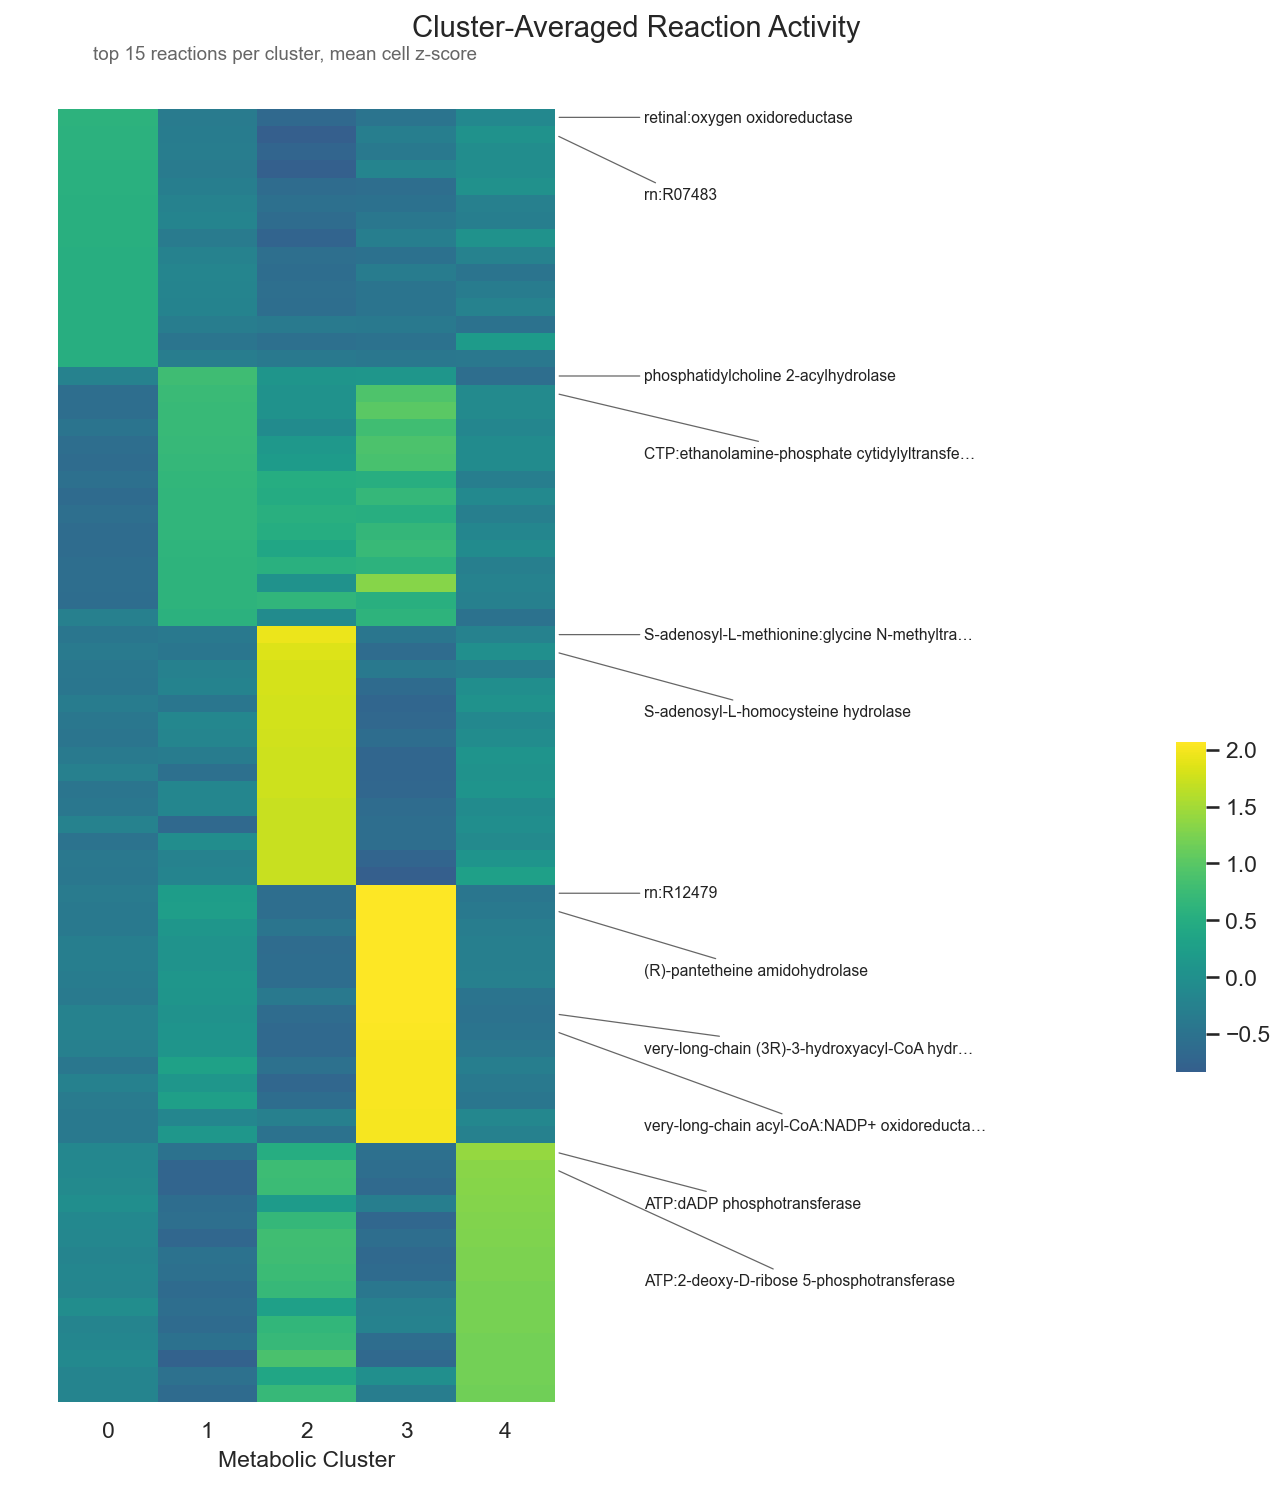

In [27]:
styled_theme(style="white", font_scale=1.0)

cluster_key = "met_leiden"
cluster_series = rna.obs[cluster_key].astype(str)

acts = enzyme_acts_mean.loc[:, enzyme_acts_mean.std(axis=0) > 0]

cell_z = acts.sub(acts.mean(axis=0), axis=1).div(acts.std(axis=0), axis=1)
z_scored = cell_z.groupby(cluster_series, observed=False).mean().T

n_rxns_per_cluster = 15
plot_data = z_scored.loc[top_features_per_cluster(z_scored, n_rxns_per_cluster)]
plot_data.index = plot_data.index.astype(str)
print(f'{len(plot_data)} reactions from {n_rxns_per_cluster} per cluster')


def rxn_display_name(rxn_id, max_chars=44):
    """A readable name for a reaction node.

    `Rxn Name` holds the KEGG enzyme name of every reaction in the node, joined by ';' where a
    node groups several; the first is enough to identify the chemistry on a figure.
    """
    raw = str(rxn_info['Rxn Name'].get(rxn_id, '')).split(';')[0].strip()
    if not raw:
        raw = rxn_id
    return raw if len(raw) <= max_chars else raw[:max_chars - 1] + '…'


# Labelling every row is unreadable, so call out a defined selection instead of none: the two
# most cluster-specific reactions per metabolic cluster, plus the most variable reactions overall.
n_per_cluster = 2
n_overall = 4
callout_rxns = []
for cluster in plot_data.columns:
    callout_rxns += (
        plot_data[cluster].sort_values(ascending=False).head(n_per_cluster).index.tolist()
    )
callout_rxns += plot_data.var(axis=1).sort_values(ascending=False).head(n_overall).index.tolist()
callout_rxns = list(dict.fromkeys(callout_rxns))
print(f'calling out {len(callout_rxns)} of the {len(plot_data)} reactions shown')

g = sns.clustermap(
    plot_data,
    cmap=HEATMAP_CMAP,
    center=0,
    row_cluster=False,
    col_cluster=False,
    xticklabels=True,
    yticklabels=False,
    figsize=(9, 10),
    dendrogram_ratio=(0.08, 0.02),
    cbar_pos=(0.90, 0.28, 0.022, 0.22),
)

g.ax_heatmap.set_xlabel("Metabolic Cluster", fontsize=11)

g.ax_heatmap.set_ylabel("")
g.ax_heatmap.tick_params(axis="x", rotation=0)

g.fig.suptitle("Cluster-Averaged Reaction Activity", fontsize=14, y=0.985)
g.fig.text(
    0.24, 0.955, f"top {n_rxns_per_cluster} reactions per cluster, mean cell z-score",
    ha="center", fontsize=9, color=STRUCTURE_COLOR,
)
g.fig.subplots_adjust(left=0.04, right=0.44, top=0.94, bottom=0.06)
g.cax.set_position([0.90, 0.28, 0.022, 0.22])

n_rows, n_cols = plot_data.shape
row_order = (
    list(g.dendrogram_row.reordered_ind)
    if g.dendrogram_row is not None
    else list(range(n_rows))
)
display_pos = {plot_data.index[original]: drawn for drawn, original in enumerate(row_order)}

points = sorted((display_pos[rxn] + 0.5, rxn) for rxn in callout_rxns)

min_gap = n_rows / (len(points) + 1) * 0.78
label_y = []
for y, _ in points:
    label_y.append(y if not label_y else max(y, label_y[-1] + min_gap))
overflow = label_y[-1] - (n_rows - 0.5)
if overflow > 0:
    label_y = [y - overflow for y in label_y]

for (row_y, rxn), text_y in zip(points, label_y):
    g.ax_heatmap.annotate(
        rxn_display_name(rxn),
        xy=(n_cols, row_y),
        xytext=(n_cols + 0.9, text_y),
        textcoords="data",
        fontsize=7.5,
        va="center",
        ha="left",
        color=TEXT_COLOR,
        arrowprops=dict(
            arrowstyle="-",
            color=STRUCTURE_COLOR,
            linewidth=0.6,
            shrinkA=0,
            shrinkB=2,
        ),
        annotation_clip=False,
    )

plt.show()

### KEGG Pathway Activity Across Metabolic Clusters

Next, we aggregate reaction activity into KEGG pathway scores. Each row is a KEGG pathway and each column is a metabolic cluster. Each pathway score is z-scored across all cells, and the values shown are the mean of those cell-level z-scores within each cluster.

Similar to the reaction-level plot above, each cluster contributes the 5 pathways it scores highest for.

25 pathways from 5 per cluster


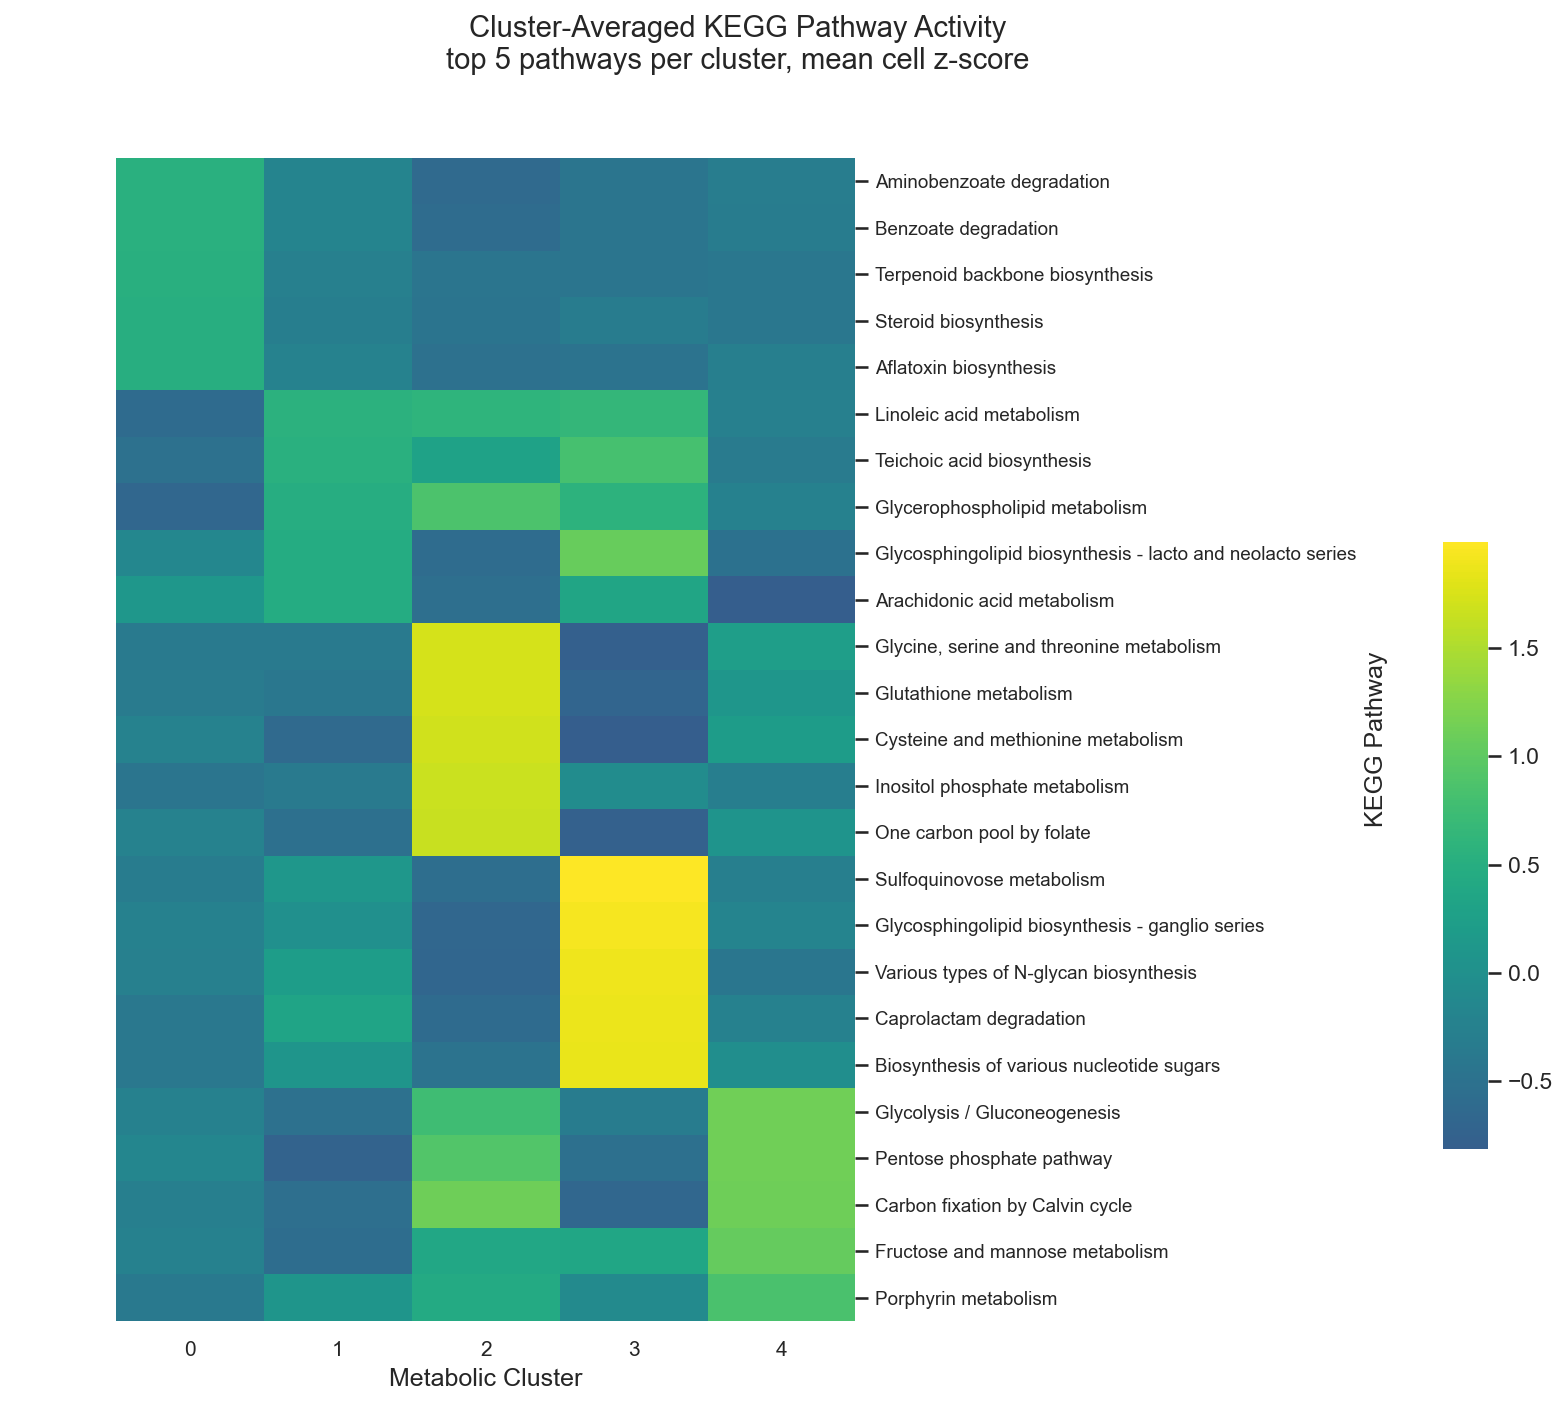

In [28]:
styled_theme(style="white", font_scale=1.0)

cluster_key = "met_leiden"
cluster_series = rna.obs[cluster_key].astype(str)

exclude_pathways = {"rn01100", "rn01110", "rn01120", "rn01200"}

ps = pathway_scores.loc[:, ~pathway_scores.columns.isin(exclude_pathways)]
ps = ps.loc[:, ps.std(axis=0) > 0]

cell_z = ps.sub(ps.mean(axis=0), axis=1).div(ps.std(axis=0), axis=1)
z_scored = cell_z.groupby(cluster_series, observed=False).mean().T

n_pathways_per_cluster = 5
plot_data = z_scored.loc[top_features_per_cluster(z_scored, n_pathways_per_cluster)]
print(f'{len(plot_data)} pathways from {n_pathways_per_cluster} per cluster')

plot_data.index = [pathway_names.get(pid, pid) for pid in plot_data.index]

g = sns.clustermap(
    plot_data,
    cmap=HEATMAP_CMAP,
    center=0,
    row_cluster=False,
    col_cluster=False,
    xticklabels=True,
    yticklabels=True,
    figsize=(10, 9),
    dendrogram_ratio=(0.12, 0.05),
    cbar_pos=(0.97, 0.2, 0.03, 0.45),
)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=0, fontsize=10)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)

g.ax_heatmap.set_xlabel("Metabolic Cluster", fontsize=12)
g.ax_heatmap.set_ylabel("KEGG Pathway", fontsize=12)
g.fig.suptitle(
    f"Cluster-Averaged KEGG Pathway Activity\n"
    f"top {n_pathways_per_cluster} pathways per cluster, mean cell z-score",
    fontsize=14, y=1.04,
)

plt.show()

### DDP Activity Across Metabolic Clusters

Finally, we summarize activity at the DDP level. Each row is a data-driven pathway and each column is a metabolic cluster. Each DDP score is z-scored across all cells, and the values shown are the mean of those cell-level z-scores within each cluster.

DDPs provide an intermediate view between individual reactions and broad KEGG pathways as they group reactions that are connected in the metabolic graph and coordinated across cells.

25 DDPs from 5 per cluster


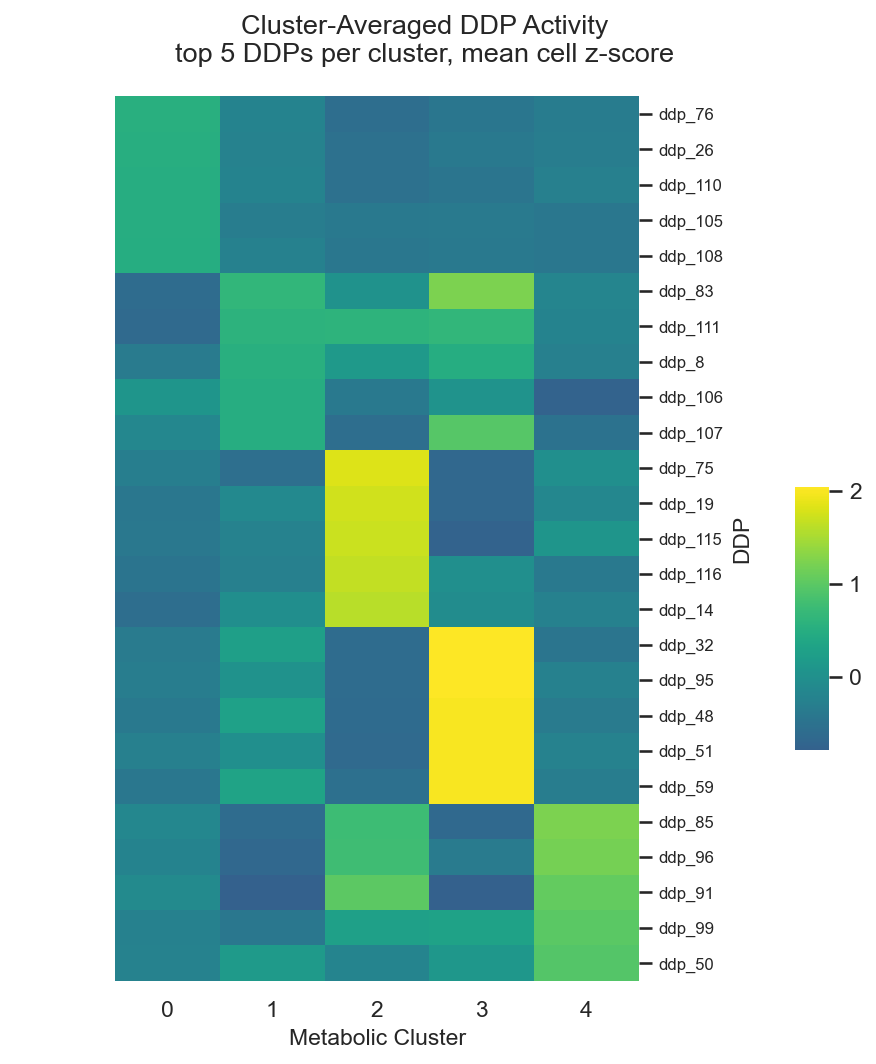

In [29]:
styled_theme(style="white", font_scale=1.0)

cluster_key = "met_leiden"
cluster_series = rna.obs[cluster_key].astype(str)

ds = ddp_scores.loc[:, ddp_scores.std(axis=0) > 0]

cell_z = ds.sub(ds.mean(axis=0), axis=1).div(ds.std(axis=0), axis=1)
z_scored = cell_z.groupby(cluster_series, observed=False).mean().T

n_ddps_per_cluster = 5
plot_data = z_scored.loc[top_features_per_cluster(z_scored, n_ddps_per_cluster)]
print(f'{len(plot_data)} DDPs from {n_ddps_per_cluster} per cluster')

plot_data.index = plot_data.index.astype(str)

g = sns.clustermap(
    plot_data,
    cmap=HEATMAP_CMAP,
    center=0,
    row_cluster=False,
    col_cluster=False,
    xticklabels=True,
    yticklabels=True,
    figsize=(6.5, 7),
    dendrogram_ratio=(0.16, 0.02)
)

g.ax_heatmap.set_xlabel("Metabolic Cluster", fontsize=11)
g.ax_heatmap.set_ylabel("DDP", fontsize=11)
g.ax_heatmap.tick_params(axis="x", rotation=0)
g.ax_heatmap.tick_params(axis="y", labelsize=8)

g.fig.suptitle(
    f"Cluster-Averaged DDP Activity\n"
    f"top {n_ddps_per_cluster} DDPs per cluster, mean cell z-score",
    fontsize=13, y=1.0,
)

g.fig.subplots_adjust(left=0.08, right=0.72, top=0.94, bottom=0.08)
g.cax.set_position([0.88, 0.30, 0.035, 0.25])

plt.show()

## Visualizing Metabolic Programs on KEGG Pathway Graphs

After summarizing reaction, KEGG pathway, and DDP activity across metabolic clusters, we can project these signals back onto metabolic pathway structure. This helps connect the matrix-level summaries to specific reactions and metabolites within known biochemical pathways.

Here we use glycolysis/gluconeogenesis as an example pathway.

### Glycolysis Reactions Colored by DDP Membership

In this plot, each edge represents a reaction in the [KEGG glycolysis/gluconeogenesis pathway (rn00010)](https://www.kegg.jp/pathway/rn00010). We color each reaction by the DDP it belongs to.

In [30]:
pathway_id_to_plot = "rn00010"

ddp_edge_labels = rxn_to_ddp.copy()

with ddp_pathway_palette(ddp_edge_labels):
    fig = mern_support.kegg_pathway_plot(
        pathway=pathway_id_to_plot,
        dataset=dataset,
        rna=rna,
        user_labels=ddp_edge_labels,
        edge_width=4,
        show_node_labels=True,
        labeled_nodes=metabolite_labels(dataset, pathway=pathway_id_to_plot),
    )

fig.update_layout(
    title="Glycolysis / Gluconeogenesis: Reactions Colored by DDP Membership"
)

fig.write_image(f"{base_path_figures}/glycolysis_ddp_plot.png", width=1200, height=800, scale=2)
fig.show()


Initiating one-time download from KEGG for mouse: rn00010. This uses KEGG access provided for academic use by academic users; you are responsible for complying with KEGG's terms. the result will be cached in memory for this dataset instance and reused.


![Glycolysis DDP plot](figures/glycolysis_ddp_plot.png)

### Glycolysis Reactions Colored by Differential Activity

We next color the glycolysis pathway by reaction-level differential activity between two metabolic
clusters. Leiden numbers its clusters in an order that depends on the cells present, so instead of
naming two ids this cell picks the contrast the figure is meant to show: the metabolic cluster with
the highest mean glycolysis activity against the one with the lowest, among clusters large enough
for the test to mean anything.

For each reaction, we compare inferred reaction activity between those two clusters using a
Wilcoxon rank-sum test. The edge color shows Cohen’s d effect size:

- positive values indicate higher inferred reaction activity in the high-glycolysis cluster
- negative values indicate higher inferred reaction activity in the low-glycolysis cluster

In [31]:
pathway_id_to_plot = "rn00010"

cluster_key = "met_leiden"
cluster_labels = rna.obs[cluster_key].astype(str)

min_cluster_cells = 100
assert pathway_id_to_plot in pathway_scores.columns, 'glycolysis is not in the pathway scores'

cluster_sizes = cluster_labels.value_counts()
eligible = cluster_sizes.index[cluster_sizes >= min_cluster_cells]
glycolysis_by_cluster = (
    pathway_scores[pathway_id_to_plot]
    .groupby(cluster_labels, observed=False)
    .mean()
    .reindex(eligible)
    .dropna()
)
up_cluster = str(glycolysis_by_cluster.idxmax())
down_cluster = str(glycolysis_by_cluster.idxmin())
print(f'cluster {up_cluster} (highest mean glycolysis activity) vs '
      f'cluster {down_cluster} (lowest), of {len(eligible)} clusters with '
      f'at least {min_cluster_cells} cells')

up_cells = rna.obs_names[cluster_labels == up_cluster]
down_cells = rna.obs_names[cluster_labels == down_cluster]

rxn_de = mern_support.wilcoxon_test(
    enzyme_acts_mean.T,
    up_cells,
    down_cells,
)

rxn_de_info = rxn_info.join(rxn_de)

edge_color_limits = (-2, 2)

edge_values = (
    rxn_de_info["cohens_d"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .clip(lower=edge_color_limits[0], upper=edge_color_limits[1])
)

fig = mern_support.kegg_pathway_plot(
    pathway=pathway_id_to_plot,
    dataset=dataset,
    rna=rna,
    user_labels=edge_values,
    edge_width=4,
    edge_color_limits=edge_color_limits,
    color_scale="RdBu_r",
    show_node_labels=True,
    labeled_nodes=metabolite_labels(dataset, pathway=pathway_id_to_plot),
)

fig.update_layout(
    title=(
        f"Glycolysis / Gluconeogenesis: Reaction Activity "
        f"Cluster {up_cluster} vs Cluster {down_cluster}"
    )
)

fig.write_image(f"{base_path_figures}/glycolysis_cohensd_plot.png", width=1200, height=800, scale=2)
fig.show()

cluster 4 (highest mean glycolysis activity) vs cluster 1 (lowest), of 5 clusters with at least 100 cells


![Glycolysis Cohen's D plot](figures/glycolysis_cohensd_plot.png)

### Identifying DDPs Connected to Glycolysis

A KEGG pathway shows reactions within a canonical pathway boundary. DDPs can extend this view by linking pathway reactions to other reactions that are coordinated with them across cells.

Here we identify all DDPs that contain at least one reaction annotated to glycolysis/gluconeogenesis. In the next plot, we expand beyond the KEGG glycolysis pathway by including all reactions from those glycolysis-associated DDPs.

In [33]:
pathway_id_to_plot = "rn00010"

glycolysis_rxns = set(pathway_rxns[pathway_id_to_plot])

glycolysis_ddps = sorted(
    rxn_to_ddp.loc[
        rxn_to_ddp.index.intersection(glycolysis_rxns)
    ]
    .dropna()
    .unique(),
    key=lambda x: int(str(x).split("_")[-1]) if str(x).split("_")[-1].isdigit() else str(x),
)

print("Glycolysis-associated DDPs:", glycolysis_ddps)


Glycolysis-associated DDPs: ['ddp_3', 'ddp_11', 'ddp_57', 'ddp_62', 'ddp_85', 'ddp_90', 'ddp_96', 'ddp_98', 'ddp_99', 'ddp_110']


In [34]:
expanded_rxns = sorted(
    set().union(*[set(ddp_rxns[ddp]) for ddp in glycolysis_ddps])
)

print("Glycolysis reactions:", len(glycolysis_rxns))
print("Expanded DDP reactions:", len(expanded_rxns))

Glycolysis reactions: 23
Expanded DDP reactions: 94


In [35]:
ddp_edge_labels = rxn_to_ddp.reindex(expanded_rxns)

expanded_labels = metabolite_labels(dataset, rxns=expanded_rxns, require_anchors=False)
print('labelled metabolites:', [dataset.compound_info[c.split('cpd:')[1]]['name'].split(';')[0]
                               for c in expanded_labels])

with ddp_pathway_palette(ddp_edge_labels):
    fig = mern_support.custom_pathway_plot(
        rxns=expanded_rxns,
        dataset=dataset,
        rna=rna,
        user_labels=ddp_edge_labels,
        edge_width=4,
        ddp_labels=rxn_to_ddp,
        ddp_color_map=ddp_color_map_for(ddp_edge_labels),
        ddp_style="soft_contours",
        show_node_labels=True,
        labeled_nodes=expanded_labels,
    )

fig.update_layout(
    title="Expanded Glycolysis-Associated DDP Network"
)

fig.write_image(f"{base_path_figures}/glycolysis_ddp_expanded_plot.png", width=1200, height=800, scale=2)
fig.show()


labelled metabolites: ['alpha-D-Glucose', 'alpha-D-Glucose 6-phosphate', 'D-Fructose 6-phosphate', 'D-Fructose 1,6-bisphosphate', 'Glycerone phosphate', 'D-Glyceraldehyde 3-phosphate', '3-Phospho-D-glyceroyl phosphate', '3-Phospho-D-glycerate', '2-Phospho-D-glycerate', 'Phosphoenolpyruvate', 'Pyruvate']


![Glycolysis DDP Expanded plot](figures/glycolysis_ddp_expanded_plot.png)

## Comparing Metabolic Coordination in a *Folr1* Knockout

Everything above describes wild-type (WT) embryogenesis. We now bring in a second dataset: embryos
carrying a *Folr1* knockout, which severely restricts the embryo's ability to capture dietary folate.

The metabolic clustering computed above resolves five metabolic states, one of which is almost
entirely depleted in the knockout. A whole-dataset comparison would therefore be dominated by
that shift in composition, so we compare a *single* metabolic state across genotypes instead.

Within a matched state, the interesting question is not only *which reactions change in mean
activity*, but *which reactions stop moving together*. A DDP is defined by coordination, so a
perturbation can leave average activity almost untouched while breaking the correlation structure
that held a DDP together. The weakest-link analysis is the tool for that comparison, applied here
across genotypes rather than across metabolic clusters.

The comparison needs three components:

1. **A shared cell population.** The knockout cells are mapped onto the wild-type metabolic states
   computed above, so we can compare the *same* metabolic state across genotypes instead of
   comparing whole datasets.
2. **Replicate-averaged reaction activity for each genotype**, decoded from its own MeRN
   replicates with the analysis behind the paper's Figure 3.
3. **One metabolic graph.** We reuse the WT reaction graph `met_g` built earlier so both genotypes are
   clustered over identical connectivity, and only the correlations differ.

### Loading Reaction Activity for Both Genotypes

Each genotype's reaction activity is the replicate ensemble of the models trained on that genotype.

- **WT:** `enzyme_acts_mean`, decoded above from the 5 replicates included with this tutorial
  (8 decodes each), to demonstrate averaging reaction activity over repeated decodes and over
  separately trained replicates.
- ***Folr1*:** the knockout models are not included, so its activity is loaded from a precomputed
  table. Following the paper's Methods, it is the ensemble mean over 8 Monte Carlo decodes for each
  of the 10 knockout replicates, restricted to the subsampled knockout cells.

In [36]:
# WT: the replicate-averaged activity decoded above with average_enzyme_activity.
wt_cells = rna.obs_names
wt_enzyme_acts_mean = enzyme_acts_mean.loc[wt_cells]

# Folr1: the knockout's own replicate ensemble, decoded from the models trained on the knockout.
folr1_enzyme_acts_mean = pd.read_csv(
    f'{base_path_data}/{folr1_activity_file}', index_col=0
)
folr1_cells = folr1_enzyme_acts_mean.index

# The reactions must match the WT activity decoded above, or the correlation structures
# compared below would not be built on the same reaction set.
assert folr1_enzyme_acts_mean.columns.equals(enzyme_acts_mean.columns)
assert not folr1_cells.isin(wt_cells).any(), 'the two genotype tables overlap'

print('WT activity:   ', wt_enzyme_acts_mean.shape)
print('Folr1 activity:', folr1_enzyme_acts_mean.shape)

WT activity:    (6000, 1213)
Folr1 activity: (5000, 1213)


### Mapping the Knockout Cells onto the Same Metabolic States

A metabolic state has to mean the same thing in both genotypes for the comparison below to work.
The wild-type clustering computed above is the **reference** and is never recomputed.

This follows the procedure of Dias et al.: every *Folr1* cell is embedded with the **wild-type**
model, placing both genotypes in one metabolic latent space; each knockout cell then takes the
majority label of its 10 closest wild-type neighbours among its 500 nearest neighbours in that
shared space. A cell is labelled `not_majority` when no state holds at least 5 of the 10 votes, and
`not_enough_neighbors` when fewer than 10 of those 500 neighbours are wild-type.

In [37]:
from sklearn.neighbors import NearestNeighbors

n_pool = 500
n_wt_vote = 10
min_votes = 5

wt_cluster_labels = rna.obs[cluster_key].astype(str)

folr1_rna = ad.read_h5ad(f'{base_path_data}/{folr1_adata_file}')[:, features_to_use].copy()
assert list(folr1_rna.var_names) == list(features_to_use)
assert folr1_rna.obs_names.equals(folr1_cells), 'activity table and object disagree on cells'

folr1_latent, _, _ = mern.get_latent_representation(folr1_rna)
print(f'Folr1 metabolic latent: {folr1_latent.shape[0]:,} cells x {folr1_latent.shape[1]} dims')

joint_latent = np.vstack([rna.obsm[metabolic_key], folr1_latent])
is_wt = np.r_[np.ones(rna.n_obs, bool), np.zeros(folr1_rna.n_obs, bool)]

neighbors = NearestNeighbors(n_neighbors=n_pool).fit(joint_latent)
_, neighbor_idx = neighbors.kneighbors(folr1_latent)

# For each knockout cell, take the 10 closest wild-type cells among its 500 neighbours and assign
# the most common state if it holds at least 5 of the 10 votes
wt_label_array = wt_cluster_labels.to_numpy()
assignments = []
for row in neighbor_idx:
    wt_neighbors = row[is_wt[row]][:n_wt_vote]
    if len(wt_neighbors) < n_wt_vote:
        assignments.append('not_enough_neighbors')
        continue
    # np.unique returns labels sorted, so argmax breaks ties toward the first label
    states, counts = np.unique(wt_label_array[wt_neighbors], return_counts=True)
    winner = counts.argmax()
    assignments.append(states[winner] if counts[winner] >= min_votes else 'not_majority')

folr1_cluster_labels = pd.Series(assignments, index=folr1_rna.obs_names)

# A UMAP of the shared embedding
joint = ad.AnnData(obs=pd.DataFrame(index=list(rna.obs_names) + list(folr1_rna.obs_names)))
joint.obsm[metabolic_key] = joint_latent
sc.pp.neighbors(joint, use_rep=metabolic_key)
sc.tl.umap(joint)
wt_umap = joint.obsm['X_umap'][:rna.n_obs]
folr1_umap = joint.obsm['X_umap'][rna.n_obs:]

state_counts = pd.DataFrame({
    'WT': wt_cluster_labels.value_counts(),
    'Folr1': folr1_cluster_labels.value_counts(),
}).fillna(0).astype(int).sort_index()
state_counts.index.name = 'metabolic state'
display(state_counts)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
Folr1 metabolic latent: 5,000 cells x 25 dims


,WT,Folr1
metabolic state,,
0,2545,1239
1,1072,1545
2,1040,859
3,754,1102
4,589,25
not_majority,0,230


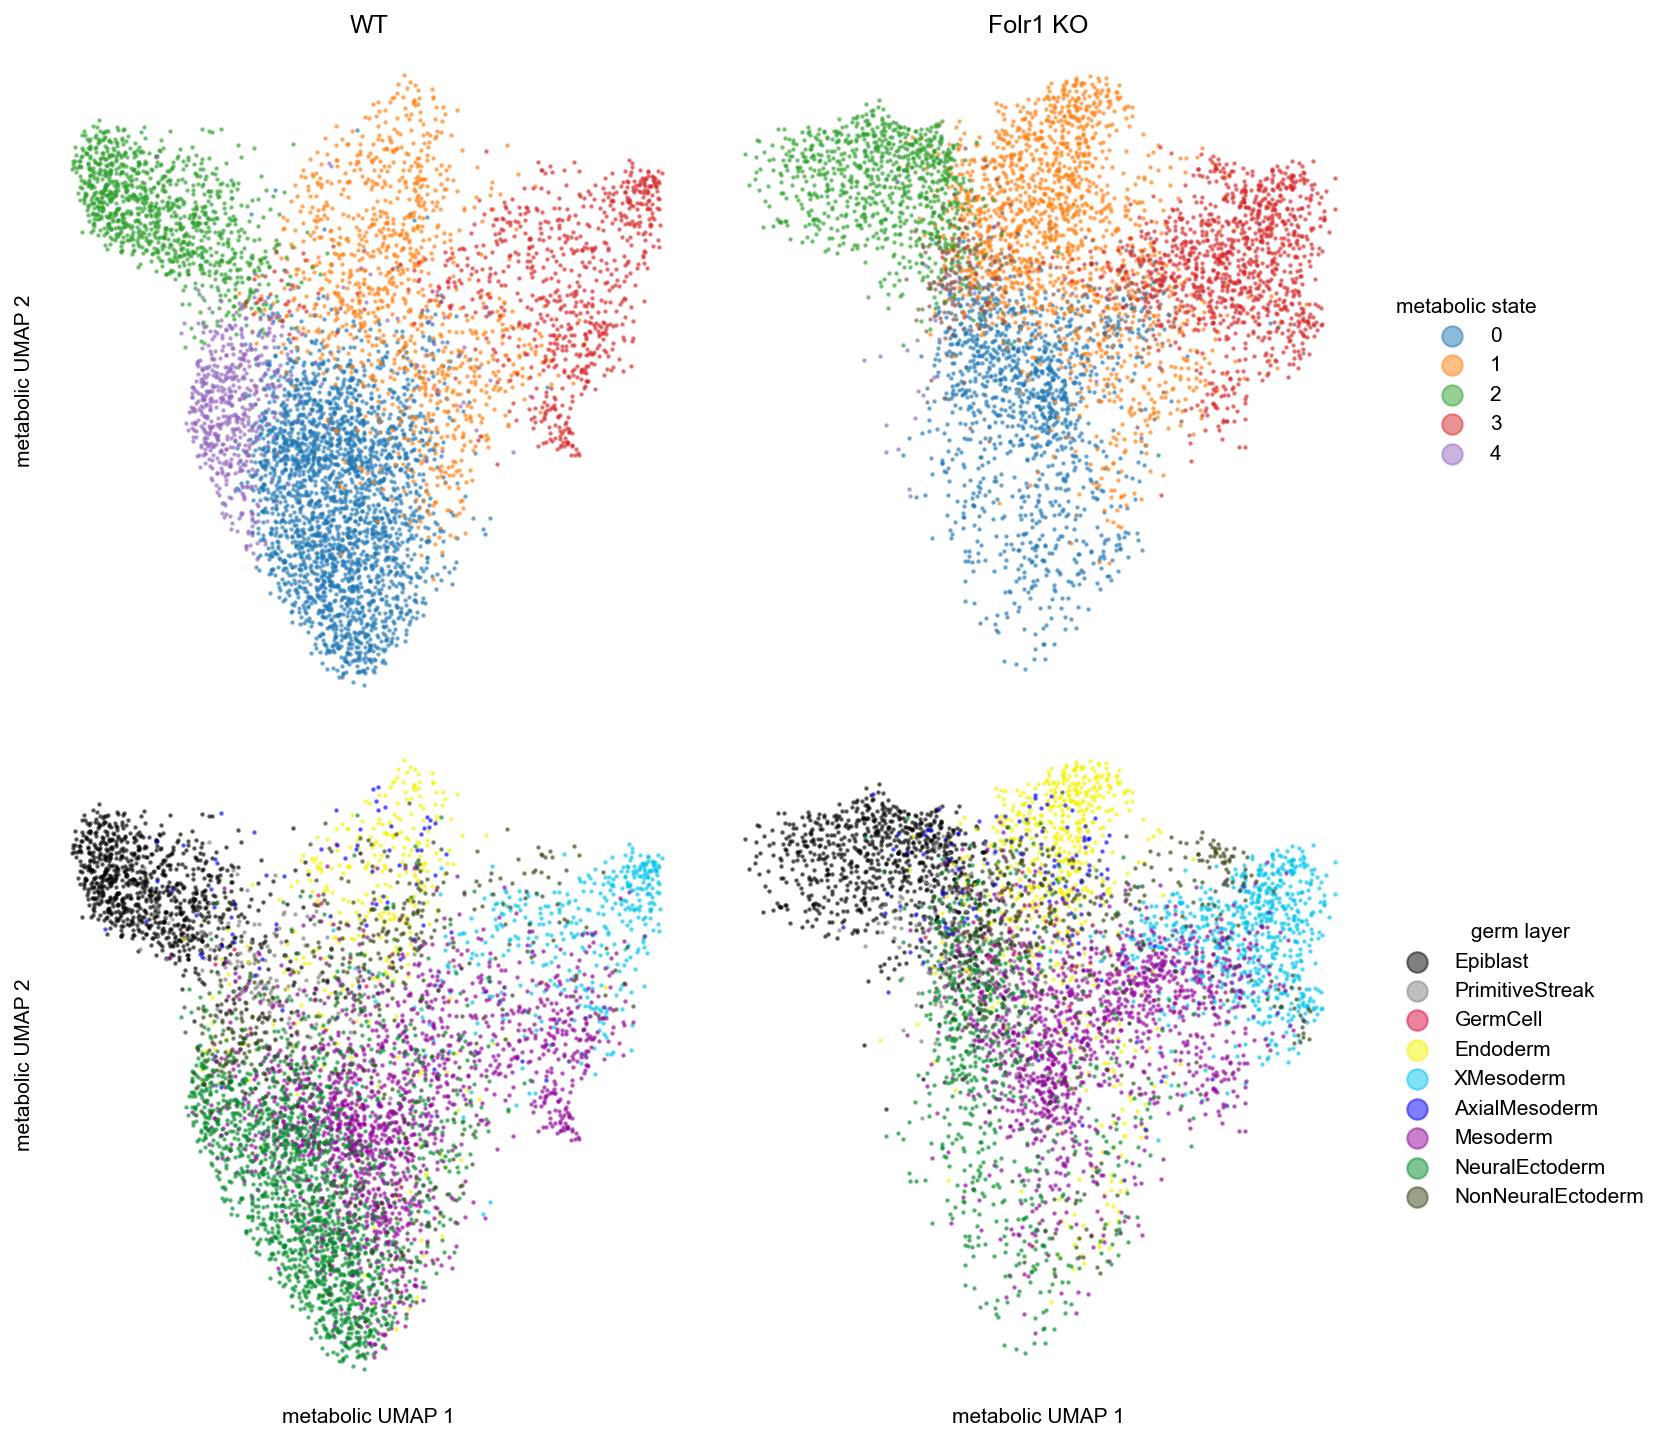

In [38]:
reset_plotting_defaults()

states = sorted(set(wt_cluster_labels) | set(folr1_cluster_labels))
state_colors = dict(zip(states, sns.color_palette('tab10', n_colors=len(states)).as_hex()))

wt_germ = rna.obs['germlayer'].astype(str)
folr1_germ = folr1_rna.obs['germlayer'].astype(str)
germlayers = [g for g in GERMLAYER_PALETTE if g in set(wt_germ) | set(folr1_germ)]
missing = (set(wt_germ) | set(folr1_germ)) - set(germlayers)
assert not missing, f'germ layers without a palette color: {missing}'

rows = [
    ('metabolic state', states, state_colors, wt_cluster_labels, folr1_cluster_labels),
    ('germ layer', germlayers, GERMLAYER_PALETTE, wt_germ, folr1_germ),
]

fig, axes = plt.subplots(
    2, 2, figsize=(11, 9.5), sharex=True, sharey=True, layout='constrained'
)
for row_i, (row_axes, (legend_title, categories, palette, wt_labels, folr1_labels)) in enumerate(
    zip(axes, rows)
):
    panels = [
        ('WT', wt_umap, wt_labels),
        ('Folr1 KO', folr1_umap, folr1_labels),
    ]
    for ax, (title, coords, labels_here) in zip(row_axes, panels):
        for category in categories:
            in_category = (labels_here == category).to_numpy()
            if not in_category.any():
                continue
            ax.scatter(
                coords[in_category, 0],
                coords[in_category, 1],
                s=1.5,
                alpha=0.5,
                color=palette[category],
                label=category if ax is row_axes[0] else None,
                rasterized=True,
            )
        if row_i == 0:
            ax.set_title(title)
        if row_i == len(rows) - 1:
            ax.set_xlabel('metabolic UMAP 1')
        ax.set_xticks([])
        ax.set_yticks([])
    row_axes[0].set_ylabel('metabolic UMAP 2')
    handles, labels = row_axes[0].get_legend_handles_labels()
    row_axes[1].legend(
        handles, labels, title=legend_title, markerscale=8,
        bbox_to_anchor=(1.02, 0.5), loc='center left', ncol=1,
    )
sns.despine(fig, left=True, bottom=True)
plt.show()

### Rebuilding DDPs Within One Metabolic State

We compare the metabolic state made up primarily of epiblast and pre-gastrulation progenitors (MS2 in Dias et al. because it is abundant in *both* genotypes and represents the
common state before gastrulation). Here the metabolic state is found by germ layer composition.

Each genotype gets its own correlation matrix, but both are clustered over the same WT graph at the same threshold.

In [39]:
state_min_corr = 0.7

germ_fractions = pd.crosstab(
    wt_cluster_labels, rna.obs['germlayer'].astype(str), normalize='index'
)
epiblast_like = [c for c in ('Epiblast', 'PrimitiveStreak') if c in germ_fractions.columns]
epiblast_score = germ_fractions[epiblast_like].sum(axis=1).sort_values(ascending=False)
comparison_state = str(epiblast_score.index[0])

print('epiblast + primitive streak fraction by metabolic state:')
print(epiblast_score.round(3).to_string())

wt_state_cells = rna.obs_names[wt_cluster_labels == comparison_state]
folr1_state_cells = folr1_cluster_labels.index[folr1_cluster_labels == comparison_state]
print(f'\ncomparison state {comparison_state}: {len(wt_state_cells)} WT cells, '
      f'{len(folr1_state_cells)} Folr1 cells')

shared_rxns = wt_enzyme_acts_mean.columns
wt_state_acts = wt_enzyme_acts_mean.loc[wt_state_cells, shared_rxns]
folr1_state_acts = folr1_enzyme_acts_mean.loc[folr1_state_cells, shared_rxns]

flat = (wt_state_acts.std(axis=0) == 0) | (folr1_state_acts.std(axis=0) == 0)
print(f'{len(shared_rxns)} reactions, {int(flat.sum())} of them flat within the state '
      f'in at least one genotype')

wt_corr = wt_state_acts.corr(method='spearman')
folr1_corr = folr1_state_acts.corr(method='spearman')

wt_ddps, wt_ddp_rxns, _, wt_linkage = mern_support.calculate_ddps(
    met_g, wt_corr, min_corr=state_min_corr
)
folr1_ddps, folr1_ddp_rxns, _, folr1_linkage = mern_support.calculate_ddps(
    met_g, folr1_corr, min_corr=state_min_corr
)

print(f'WT DDPs in state {comparison_state}:    {len(wt_ddp_rxns)}')
print(f'Folr1 DDPs in state {comparison_state}: {len(folr1_ddp_rxns)}')

folate_rxns = ['rn:R04325 rn:R06974', 'rn:R04209']
folate_ddps = sorted(set(wt_ddps.reindex(folate_rxns).dropna()))
print('folate reactions:', {r: wt_ddps.get(r) for r in folate_rxns})
folate_ddp = folate_ddps[0] if len(folate_ddps) == 1 else None
if folate_ddp is None:
    print('the two folate reactions are not in a single WT DDP:', folate_ddps)

epiblast + primitive streak fraction by metabolic state:
met_leiden
2    0.924
4    0.046
3    0.042
1    0.035
0    0.024

comparison state 2: 1040 WT cells, 859 Folr1 cells
1213 reactions, 0 of them flat within the state in at least one genotype
WT DDPs in state 2:    115
Folr1 DDPs in state 2: 140
folate reactions: {'rn:R04325 rn:R06974': 'ddp_89', 'rn:R04209': 'ddp_89'}


### WT DDPs Across Central Carbon and Nucleotide Metabolism

Before scoring what breaks, it helps to see what the WT programs *are*. We take every DDP that
touches glycolysis, pentose phosphate, purine, or pyrimidine metabolism and draw all of their
reactions on the reaction graph, colored by DDP membership. Each DDP is a connected, coordinated
block, and the layout separates the four pathway neighborhoods.

`folate_ddp` sits in purine metabolism: its reactions are consecutive steps of de novo purine
synthesis, the route that consumes a pentose phosphate pathway product to build the purine ring.

Only WT DDPs appear here. The knockout's own DDPs are never used as groups: the weakest-link
analysis below keeps the WT DDPs fixed and uses the knockout's correlations and clustering
hierarchy only to score how well each WT DDP holds together.

In [40]:
pathways_of_interest = ['rn00010', 'rn00030', 'rn00230', 'rn00240']

keep_ddps = set()
keep_rxns = set()
for rxn in shared_rxns:
    if rxn not in rxn_info.index:
        continue
    rxn_pathways = str(rxn_info.loc[rxn, 'Pathways']).split(';')
    if not set(rxn_pathways) & set(pathways_of_interest):
        continue
    keep_rxns.add(rxn)
    if rxn in wt_ddps.index and wt_ddps[rxn] is not None and not pd.isnull(wt_ddps[rxn]):
        keep_ddps.add(wt_ddps[rxn])

for ddp in keep_ddps:
    keep_rxns.update(wt_ddp_rxns[ddp])

keep_rxns = sorted(keep_rxns)
print(f'{len(keep_ddps)} DDPs touch the selected pathways, spanning {len(keep_rxns)} reactions')


24 DDPs touch the selected pathways, spanning 258 reactions


In [41]:
wt_labels = wt_ddps.where(wt_ddps.index.isin(keep_rxns), None)

keep_labels = metabolite_labels(dataset, rxns=keep_rxns, require_anchors=False)
print('labelled metabolites:', [dataset.compound_info[c.split('cpd:')[1]]['name'].split(';')[0]
                               for c in keep_labels])

with ddp_pathway_palette(wt_labels):
    fig = mern_support.custom_pathway_plot(
        rxns=keep_rxns,
        dataset=dataset,
        rna=rna,
        user_labels=wt_labels,
        show_node_labels=True,
        labeled_nodes=keep_labels,
    )
fig.update_layout(title='Selected reactions colored by WT DDP membership')
fig.write_image(f"{base_path_figures}/folr1_ddp_plot.png", width=1200, height=800, scale=2)
fig.show()


labelled metabolites: ['alpha-D-Glucose', 'alpha-D-Glucose 6-phosphate', 'D-Fructose 6-phosphate', 'D-Fructose 1,6-bisphosphate', 'Glycerone phosphate', 'D-Glyceraldehyde 3-phosphate', '3-Phospho-D-glyceroyl phosphate', '3-Phospho-D-glycerate', '2-Phospho-D-glycerate', 'Phosphoenolpyruvate', 'Pyruvate']


![Folr1 DDP Plot](figures/folr1_ddp_plot.png)

### Weakest-Link Analysis Across Genotypes

We now run the structural-break calculation with WT as the reference state and *Folr1* as the
comparison state. Every reaction in a DDP is, by construction, correlated with its DDP partners in
WT; holding those groups fixed and recomputing the correlations in the knockout shows which pairs
the WT definition no longer describes.

Each point is a WT DDP. For each one we take the weakest correlation between any two of its
reactions in WT, and subtract the weakest correlation between any two of its reactions in the
knockout. The y-axis does this on the raw reaction correlations; the x-axis does it on the cophenetic
correlations, which registers whether the drop also reorganizes the clustering hierarchy. DDPs in the
upper right lose coordination in the knockout on both measures.

This is the weakest-link analysis of the paper's Methods. The two statistics are `min_corr_drop` and `min_cophenetic_drop` the drops in the minimum raw and cophenetic correlation over all reaction pairs within a DDP.

`folate_ddp` is highlighted with the
top-ranked breaks labeled alongside it.

In [42]:
# A DDP with at least two reactions to work through. The folate DDP when it is well defined,
# otherwise the largest WT DDP in this metabolic state.
if folate_ddp is not None:
    focus_ddp = folate_ddp
else:
    focus_ddp = max(wt_ddp_rxns, key=lambda d: len(wt_ddp_rxns[d]))
    print(f'folate reactions did not form a single DDP; using the largest instead')

focus_rxns = [rxn for rxn in wt_ddp_rxns[focus_ddp] if rxn in wt_corr.index]
focus_pairs = list(itertools.combinations(focus_rxns, 2))
print(f'{focus_ddp}: {len(focus_rxns)} reactions, {len(focus_pairs)} pairs\n')

# Cophenetic correlations: the level at which each pair first joins in the hierarchy.
# The linkage stores distance as 1 - correlation, which this helper converts back.
labels = list(wt_corr.index)
wt_cophenetic = mern_support.calculate_cophenetic_corr_matrix(wt_linkage, labels)
folr1_cophenetic = mern_support.calculate_cophenetic_corr_matrix(folr1_linkage, labels)


def pair_values(matrix, pairs):
    """The matrix entry for each reaction pair, indexed by the pair."""
    return pd.Series({pair: matrix.loc[pair[0], pair[1]] for pair in pairs})


wt_raw = pair_values(wt_corr, focus_pairs)
folr1_raw = pair_values(folr1_corr, focus_pairs)
wt_coph = pair_values(wt_cophenetic, focus_pairs)
folr1_coph = pair_values(folr1_cophenetic, focus_pairs)

# The weakest link in each condition is the minimum over the DDP's pairs.
m_raw_wt, m_raw_folr1 = wt_raw.min(), folr1_raw.min()
m_coph_wt, m_coph_folr1 = wt_coph.min(), folr1_coph.min()

# The statistics are the drops from the reference condition to the alternate one.
delta_raw = m_raw_wt - m_raw_folr1
delta_coph = m_coph_wt - m_coph_folr1

print(f'weakest raw correlation        WT {m_raw_wt:6.3f}  ->  Folr1 {m_raw_folr1:6.3f}'
      f'   drop {delta_raw:+.3f}')
print(f'weakest cophenetic correlation WT {m_coph_wt:6.3f}  ->  Folr1 {m_coph_folr1:6.3f}'
      f'   drop {delta_coph:+.3f}')
print(f'\nweakest pair in WT:    {wt_raw.idxmin()}')
print(f'largest drop in a pair: {(wt_raw - folr1_raw).idxmax()} '
      f'({(wt_raw - folr1_raw).max():+.3f})')

ddp_89: 9 reactions, 36 pairs

weakest raw correlation        WT  0.732  ->  Folr1 -0.004   drop +0.736
weakest cophenetic correlation WT  0.732  ->  Folr1 -0.216   drop +0.948

weakest pair in WT:    ('rn:R04144', 'rn:R04560 rn:R06975')
largest drop in a pair: ('rn:R04144', 'rn:R04378') (+0.809)


In [44]:
folr1_breaks = mern_support.calculate_ddp_structural_breaks(
    wt_ddps,
    wt_corr,
    wt_linkage,
    folr1_corr,
    folr1_linkage,
)

display(folr1_breaks.sort_values('min_cophenetic_drop', ascending=False).head(10))

# the same two numbers derived by hand above for the DDP worked through there
focus_row = folr1_breaks.set_index('ddp').loc[focus_ddp]
assert np.isclose(focus_row['min_corr_drop'], delta_raw)
assert np.isclose(focus_row['min_cophenetic_drop'], delta_coph)
print(f'\n{focus_ddp}: hand-computed drops match calculate_ddp_structural_breaks')

,rank,ddp,n_reactions,n_pairs,wt_mean_corr,ko_mean_corr,mean_corr_drop,wt_min_corr,ko_min_corr,min_corr_drop,largest_corr_drop_pair,wt_mean_cophenetic_corr,ko_mean_cophenetic_corr,mean_cophenetic_drop,wt_min_cophenetic_corr,ko_min_cophenetic_corr,min_cophenetic_drop,largest_cophenetic_drop_pair,reactions
12,13,ddp_90,10,45,0.886285,0.909412,-0.023128,0.802393,0.716240,0.086153,"(rn:R08639, rn:R03418 rn:R03634)",0.863701,0.609744,0.253956,0.802393,-0.558746,1.361139,"(rn:R08639, rn:R00801)","[rn:R08639, rn:R00801, rn:R00299 rn:R00303, rn..."
0,1,ddp_6,3,3,0.866315,0.793012,0.073303,0.835219,0.664555,0.170664,"(rn:R13223, rn:R01082)",0.851187,-0.033048,0.884235,0.835219,-0.503417,1.338636,"(rn:R02164 rn:R00402 rn:R10660 rn:R13137, rn:R...","[rn:R02164 rn:R00402 rn:R10660 rn:R13137, rn:R..."
1,2,ddp_79,7,21,0.884537,0.769889,0.114648,0.776347,0.477524,0.298822,"(rn:R07364, rn:R01920)",0.841232,0.089518,0.751715,0.776347,-0.469733,1.246080,"(rn:R07364, rn:R07392)","[rn:R07364, rn:R07363, rn:R07395, rn:R07392, r..."
26,27,ddp_113,34,561,0.937960,0.895327,0.042633,0.762080,0.380946,0.381134,"(rn:R07324, rn:R05795)",0.902773,0.782786,0.119987,0.762080,-0.469733,1.231813,"(rn:R01184, rn:R07324)","[rn:R01184, rn:R01187 rn:R07279, rn:R04372, rn..."
2,3,ddp_65,6,15,0.828596,0.722176,0.106420,0.724122,0.401180,0.322942,"(rn:R00667, rn:R00111 rn:R11713)",0.801137,0.065289,0.735848,0.724122,-0.503417,1.227539,"(rn:R00667, rn:R00551)","[rn:R00667, rn:R00669 rn:R02282, rn:R00551, rn..."
15,16,ddp_87,9,36,0.884322,0.909666,-0.025344,0.768899,0.794129,-0.025230,"(rn:R01529, rn:R01519)",0.833466,0.617332,0.216133,0.768899,-0.341876,1.110776,"(rn:R01526, rn:R01056)","[rn:R01641, rn:R01528 rn:R10221, rn:R02035, rn..."
3,4,ddp_89,9,36,0.870766,0.516266,0.354501,0.731661,-0.004195,0.735856,"(rn:R04144, rn:R04378)",0.810643,0.177265,0.633377,0.731661,-0.216308,0.947970,"(rn:R04144, rn:R04209)","[rn:R04144, rn:R04325 rn:R06974, rn:R04463, rn..."
9,10,ddp_93,11,55,0.786857,0.805276,-0.018419,0.730257,0.698396,0.031861,"(rn:R03045, rn:R03383)",0.748052,0.474173,0.273879,0.730257,-0.198956,0.929213,"(rn:R00923 rn:R00930 rn:R01859, rn:R02765)","[rn:R03045, rn:R00919 rn:R04432 rn:R10161 rn:R..."
4,5,ddp_109,23,253,0.911198,0.906875,0.004323,0.746002,0.764555,-0.018553,"(rn:R02092 rn:R02094, rn:R01655)",0.862354,0.505595,0.356760,0.746002,-0.165245,0.911247,"(rn:R02101, rn:R02237)","[rn:R02101, rn:R02092 rn:R02094, rn:R01567 rn:..."
8,9,ddp_73,7,21,0.793121,0.761227,0.031894,0.729897,0.596390,0.133506,"(rn:R00238, rn:R02488)",0.758585,0.474157,0.284428,0.729897,-0.160357,0.890254,"(rn:R01171 rn:R01175, rn:R02488)","[rn:R00238, rn:R01978, rn:R01176 rn:R01179, rn..."



ddp_89: hand-computed drops match calculate_ddp_structural_breaks


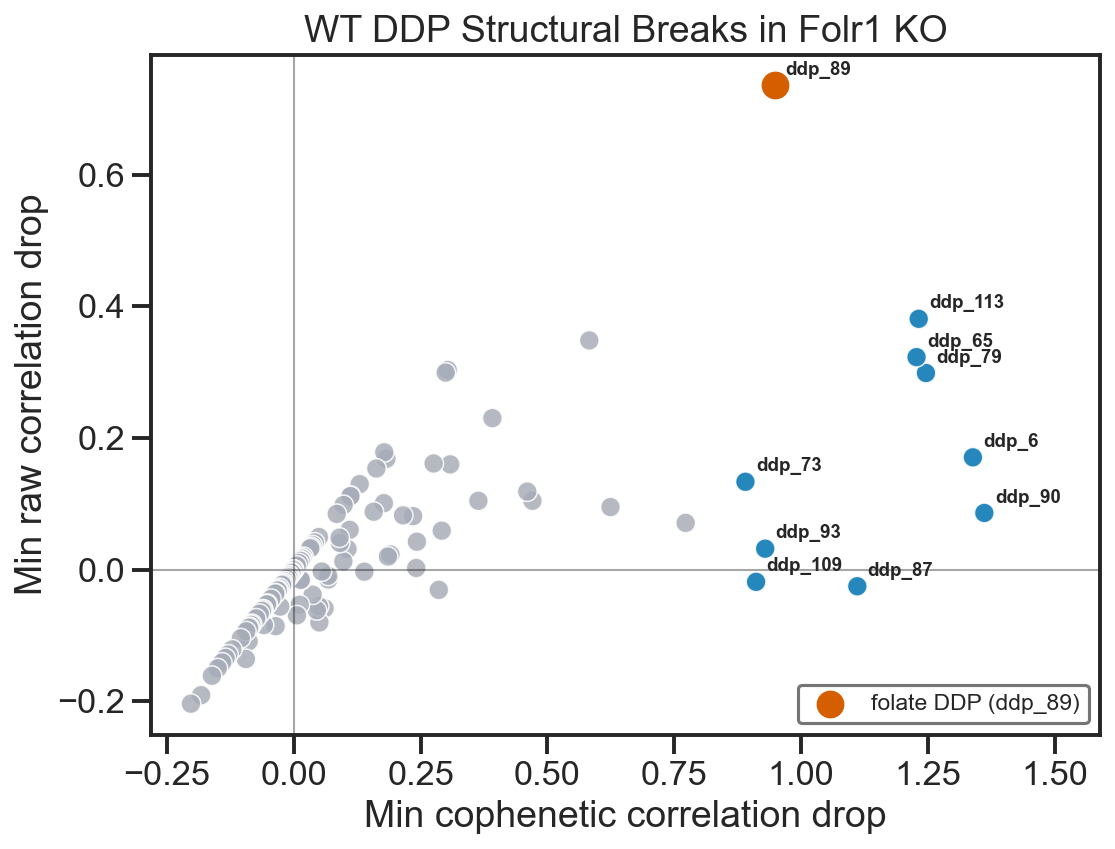

In [45]:
top_n = 10
folr1_breaks = folr1_breaks.copy()

folr1_breaks = folr1_breaks.sort_values("min_cophenetic_drop", ascending=False)
folr1_breaks["min_cophenetic_drop_rank"] = range(1, len(folr1_breaks) + 1)
folr1_breaks["is_top"] = folr1_breaks["min_cophenetic_drop_rank"] <= top_n
# folate_ddp is None when the two folate reactions did not land in a single WT DDP.
folr1_breaks["is_folate"] = (
    folr1_breaks["ddp"].astype(str).eq(str(folate_ddp)) if folate_ddp is not None else False
)

styled_theme(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=folr1_breaks,
    x="min_cophenetic_drop",
    y="min_corr_drop",
    hue="is_top",
    palette={True: OBSERVED_COLOR, False: BACKGROUND_COLOR},
    s=90,
    alpha=0.85,
    legend=False,
    ax=ax,
)

folate_row = folr1_breaks.loc[folr1_breaks["is_folate"]]
ax.scatter(
    folate_row["min_cophenetic_drop"],
    folate_row["min_corr_drop"],
    color=HIGHLIGHT_COLOR,
    s=140,
    zorder=5,
    label=f"folate DDP ({folate_ddp})",
)
if not folate_row.empty:
    ax.legend(
        frameon=True, fontsize=11, edgecolor=STRUCTURE_COLOR,
        facecolor='white', framealpha=0.9,
    )

ax.axhline(0, color="black", linewidth=1, alpha=0.35)
ax.axvline(0, color="black", linewidth=1, alpha=0.35)
ax.grid(False)

for _, row in folr1_breaks.loc[folr1_breaks["is_top"] | folr1_breaks["is_folate"]].iterrows():
    ax.annotate(
        str(row["ddp"]),
        (row["min_cophenetic_drop"], row["min_corr_drop"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        weight="bold",
    )

ax.set_title("WT DDP Structural Breaks in Folr1 KO")
ax.set_xlabel("Min cophenetic correlation drop")
ax.set_ylabel("Min raw correlation drop")

fig.tight_layout()
ax.set_xlim(right=ax.get_xlim()[1] + 0.15)
plt.show()
